# Generalized E3SMLE and CESM-SMYLE Global RMSE Skill Maps

This notebook computes and plots seasonal skill for `TREFHT`, `PRECT`, or `PSL` using the same workflow.

Change only one line in the configuration cell below:

```python
# field = "TREFHT"  # surface air temperature
# field = "PRECT" # precipitation
# field = "PSL"   # sea-level pressure
```

Variable-specific observation product, observation variable name, unit conversion, labels, and cache filenames are handled through `VAR_CONFIG`.


In [1]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path
import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
#from esp_lab import data_access_smyle.py as data_access
from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import colorbar_utils as cbars
from esp_lab.utils import regrid_utils as regrid
from esp_lab.utils import mov_utils as mov
from esp_lab.paths import (
    S2D_DIAG_ROOT,
    E3SMLE_DIAG_DIR,
    CESM_SMYLE_DIAG_DIR,
    NMME_DIAG_DIR,
    MODES_VARIABILITY_DIAG_DIR,
)

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"

from esp_lab.utils.dask_util import DaskConfig, get_cluster_client, close_cluster


Warning 3: Cannot find header.dxf (GDAL_DATA is not defined)


In [2]:
import dask
from dask.distributed import (
    wait,
    get_client
)
dask.__version__

'2026.3.0'

## Preprocessing:  Data I/O using Dask

### Create Dask Cluster

In [3]:
machine_env = os.environ.get('CLUSTER_TYPE', 'local') 

# Clean up any existing active clients/clusters
try:
    from dask.distributed import get_client
    client = get_client()
    client.close()
except:
    pass

try:
    cluster.close()
except:
    pass

# Initialize using the centralized esp_lab utility
dask_cfg = DaskConfig(cluster_type=machine_env, workers=30)
cluster, client = get_cluster_client(dask_cfg)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41015 instead
  warnings.warn(
2026-07-20 01:58:46,226 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4c3e56d2b0d428c1f72b48416bc57419 initialized by task ('rechunk-merge-rechunk-transfer-54146eec366925683be2bfa9a35d5ca5', 0, 0, 0, 2, 1, 0, 0, 3, 2, 1) executed on worker tcp://127.0.0.1:44405
2026-07-20 01:58:46,461 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d69c0984be6345571e58b2bb6ac49fd6 initialized by task ('rechunk-merge-rechunk-transfer-54146eec366925683be2bfa9a35d5ca5', 0, 0, 0, 1, 1, 0, 0, 3, 1, 1) executed on worker tcp://127.0.0.1:38473
2026-07-20 01:58:47,424 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 2a3b76cec62b335ade591c569cbbf7e9 initialized by task ('rechunk-merge-rechunk-transfer-54146eec366925683be2bfa9a

In [4]:
cluster

LocalCluster(d9d2b245, 'tcp://127.0.0.1:39993', workers=4, threads=4, memory=14.90 GiB)

### Read in EAM monthly data; Convert to Seasonal averages (DJF, MAM, JJA, SON)
- Chosen field is returned as a dask array with leading dimensions of Y (initialization year), M (ensemble member), and L (lead season). For example, for November starts, L=1 corresponds to first DJF season.
- "time" which gives prediction verification time (centered time for a given season) is also dimensioned with (Y,L)

In [5]:
%%time
# =============================================================================
# CONFIGURATION BLOCK: Edit settings here
# =============================================================================

# ===== DIRECTORY AND PATHS CONFIGURATION =====
# Import paths from esp_lab.paths; override here if needed
from esp_lab.paths import (
    S2D_DIAG_ROOT,
    E3SMLE_DIAG_DIR,
    CESM_SMYLE_DIAG_DIR,
    NMME_DIAG_DIR,
    MODES_VARIABILITY_DIAG_DIR,
)

# Directory setup
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR

# Clean model-first diagnostic layout helpers.
# E3SMLE_DIAG_DIR is kept as a backwards-compatible variable name, but it now
# points to the S2D diagnostic root; each case lives under its cache_tag.
E3SM_DIAG_ROOT = Path(E3SMLE_OUTDIR)

def e3sm_case_dir(case_info):
    return E3SM_DIAG_ROOT / case_info["cache_tag"]

def e3sm_leadtime_dir(case_info, stage, *parts):
    path = e3sm_case_dir(case_info) / "leadtime_acc" / str(stage) / "atm"
    for part in parts:
        path = path / str(part)
    return path

def smyle_leadtime_dir(stage, *parts):
    path = Path(CESM_SMYLE_OUTDIR) / "leadtime_acc" / str(stage) / "atm"
    for part in parts:
        path = path / str(part)
    return path
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

# Post-processed data directory candidates
DATA_DIR_CANDIDATES = [
    "/global/cfs/cdirs/e3sm/S2S2D/post_process",
    "/global/cfs/cdirs/e3smdata/simulations/S2S2D/post_process",
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if os.path.exists(p)), DATA_DIR_CANDIDATES[0])

# ===== FIELD AND VARIABLE CONFIGURATION =====
# Change this one line to switch diagnostics:
#   field = "TREFHT"  -> ERA5 tas, model/obs K -> degC
#   field = "PRECT"   -> GPCP PRECT, model m/s -> mm/day
#   field = "PSL"     -> ERA5 psl, model/obs Pa -> hPa
#field = "TREFHT"
#field = "PRECT"
field = "PSL"

# ===== UNIT CONVERSION FUNCTIONS =====
def convert_kelvin_to_celsius(da):
    """Convert K to degC while preserving lazy evaluation."""
    da = da - 273.15
    da.attrs["units"] = r"$^\circ$C"
    return da

def convert_precip_mps_to_mmday(da):
    """Convert precipitation from m/s to mm/day while preserving lazy evaluation."""
    da = da * (1000.0 * 86400.0)
    da.attrs["units"] = "mm/day"
    return da

def convert_pa_to_hpa(da):
    """Convert pressure from Pa to hPa while preserving lazy evaluation."""
    da = da * 1.0e-2
    da.attrs["units"] = "hPa"
    return da

def no_unit_conversion(da, units=None):
    """Return a lazy copy and optionally standardize the unit attribute."""
    da = da * 1.0
    if units is not None:
        da.attrs["units"] = units
    return da

# ===== VARIABLE CONFIGURATION =====
VAR_CONFIG = {
    "TREFHT": {
        "long_name": "2-m air temperature",
        "plot_name": "Surface air temperature",
        "obs_name": "ERA5",
        "obs_var": "tas",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_kelvin_to_celsius,
        "smyle_convert": convert_kelvin_to_celsius,
        "obs_convert": convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
    },
    "PRECT": {
        "long_name": "precipitation",
        "plot_name": "Precipitation",
        "obs_name": "GPCP_v2.3",
        "obs_var": "PRECT",
        "obs_ys": "1979",
        "obs_ye": "2017",
        "model_convert": convert_precip_mps_to_mmday,
        "smyle_convert": convert_precip_mps_to_mmday,
        # GPCP PRECT from this archive is already mm/day.
        "obs_convert": lambda da: no_unit_conversion(da, units="mm/day"),
        "units": "mm/day",
    },
    "PSL": {
        "long_name": "sea-level pressure",
        "plot_name": "Sea-level pressure",
        "obs_name": "ERA5",
        "obs_var": "psl",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_pa_to_hpa,
        "smyle_convert": convert_pa_to_hpa,
        "obs_convert": convert_pa_to_hpa,
        "units": "hPa",
    },
}

if field not in VAR_CONFIG:
    raise ValueError(f"Unsupported field={field!r}. Available fields: {list(VAR_CONFIG)}")

cfg = VAR_CONFIG[field]

# Field-specific map colorbar configuration
MAP_COLORBAR_CONFIG = {
    "absolute_rmse": {
        "TREFHT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                   "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PRECT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                  "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PSL": {"levels": [0, 2, 4, 6, 8, 10, 12],
                "ticks": [0, 2, 4, 6, 8, 10, 12], "decimals": 1},
    },
    "normalized_rmse_difference": {
        "TREFHT": {"levels": [-0.5, -0.45, -0.4, -0.35, -0.3, -0.25,
                              -0.2, -0.15, -0.1, -0.05, 0,
                              0.05, 0.1, 0.15, 0.2, 0.25,
                              0.3, 0.35, 0.4, 0.45, 0.5],
                   "ticks": [-0.5, -0.25, 0, 0.25, 0.5], "decimals": 2},
        "PRECT": {"levels": [-0.5, -0.45, -0.4, -0.35, -0.3, -0.25,
                             -0.2, -0.15, -0.1, -0.05, 0,
                             0.05, 0.1, 0.15, 0.2, 0.25,
                             0.3, 0.35, 0.4, 0.45, 0.5],
                  "ticks": [-0.5, -0.25, 0, 0.25, 0.5], "decimals": 2},
        "PSL": {"levels": [-0.6, -0.5, -0.4, -0.3, -0.2, -0.1,
                           0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
                "ticks": [-0.6, -0.3, 0, 0.3, 0.6], "decimals": 1},
    },
}

def map_colorbar_settings(plot_type, field):
    config = MAP_COLORBAR_CONFIG[plot_type][field]
    levels = np.asarray(config["levels"], dtype=float)
    ticks = np.asarray(config["ticks"], dtype=float)
    steps = np.diff(levels)
    if levels.ndim != 1 or levels.size < 2 or np.any(steps <= 0):
        raise ValueError(f"Invalid colorbar levels for {plot_type}/{field}")
    if not np.allclose(steps, steps[0]):
        raise ValueError(
            f"Map helper requires uniform levels for {plot_type}/{field}"
        )
    if np.any(ticks < levels[0]) or np.any(ticks > levels[-1]):
        raise ValueError(f"Ticks outside levels for {plot_type}/{field}")
    return levels, ticks, int(config["decimals"])

rmse_levels, rmse_ticks, rmse_decimals = map_colorbar_settings(
    "absolute_rmse", field
)
nrmse_diff_levels, nrmse_diff_ticks, nrmse_diff_decimals = map_colorbar_settings(
    "normalized_rmse_difference", field
)

print(f"Selected field: {field} ({cfg['long_name']})")
print(f"Observation product: {cfg['obs_name']} variable={cfg['obs_var']}")
print(f"Using post-processed data directory: {DATA_DIR}")

# ===== MULTI-CASE E3SM HINDCAST CONFIGURATION =====
# Add more entries here as new post-processed hindcasts land under DATA_DIR
E3SM_CASES = {
    "E3SM-FOSIRL": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "cache_tag": "JRA55_FOSIRL",
        "display_name": "E3SMv3-FOSIRL",
    },
    "E3SM-Reanalysis": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "cache_tag": "Reanalysis",
        "display_name": "E3SMv3-Reanalysis",
    },
#    "E3SM-4DEnVarOcn": {
#        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
#        "cache_tag": "4DEnVarOcn",
#        "display_name": "E3SMv3-4DEnVarOcn",
#    },
}

# Which E3SM case should old single-case cells/variables point to
E3SM_REFERENCE_CASE = "E3SM-FOSIRL"

# ===== ENSEMBLE AND HINDCAST PARAMETERS =====
case_nens = 10
case_nlead = 24
engine = "netcdf4"

years = 1980
yeare = 2018
yexcl = None

# Shared climatology window for drift removal, skill calculation, and checks
climy0 = 1981
climy1 = 2010
init_months = [5, 11]

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]
INIT_YEARS_BY_MONTH = {init_month: lead_years for init_month in init_months}
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"
grid = "180x360_aave"
freq = "monthly"
ts_split = "2yr"

require_all_members = True
verify_field_name = True
verify_coverage = True
debug = True

# Optional: safer open-time chunking
chunks_open = {}  # {"L": 24} can be used if needed

mchunk = {
    "Y": 3,
    "L": 24,
    "M": 2,
    "lat": 90,
    "lon": 180,
}

# ===== END CONFIGURATION BLOCK =====

e3sm_raw_by_case_month = {}

for case_key, case_info in E3SM_CASES.items():
    case_prefix = case_info["case_prefix"]
    e3sm_raw_by_case_month[case_key] = {}

    print("")
    print("=" * 80)
    print(f"Loading {case_key}: {case_prefix}")

    for init_month in init_months:
        init_tags = data_access.build_init_tags(INIT_YEARS_BY_MONTH[init_month], init_month)

        e3sm = data_access.get_monthly_data(
            data_dir=DATA_DIR,
            case_prefix=case_prefix,
            members=members,
            init_tags=init_tags,
            field=field,
            nlead=case_nlead,
            chunks=chunks_open,
            realm=realm,
            grid=grid,
            freq=freq,
            ts_split=ts_split,
            require_all_members=require_all_members,
            verify_field_name=verify_field_name,
            verify_coverage=verify_coverage,
            engine=engine,
        )

        print(f"{case_key} init_month={init_month}, size={e3sm.nbytes / 1e9:.2f} GB")

        # Apply final chunking after combine
        e3sm = e3sm.chunk(mchunk)

        if debug:
            print(e3sm)
            print(e3sm.dims)
            print(e3sm.Y.values)
            print(e3sm.L.values[:5], e3sm.L.values[-5:])
            print(e3sm.time.isel(Y=0, L=slice(0, 3)).values)

        e3sm_raw_by_case_month[case_key][init_month] = e3sm

# Backward-compatible aliases for older exploratory cells
e3smle_by_month = e3sm_raw_by_case_month[E3SM_REFERENCE_CASE]
e3smle05 = e3smle_by_month.get(5)
e3smle11 = e3smle_by_month.get(11)

Selected field: PSL (sea-level pressure)
Observation product: ERA5 variable=psl
Using post-processed data directory: /global/cfs/cdirs/e3sm/S2S2D/post_process

Loading E3SM-FOSIRL: WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL
E3SM-FOSIRL init_month=5, size=2.43 GB
<xarray.Dataset> Size: 2GB
Dimensions:  (Y: 39, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    time     (Y, L) object 7kB dask.array<chunksize=(3, 24), meta=np.ndarray>
    PSL      (Y, L, M, lat, lon) float32 2GB dask.array<chunksize=(3, 24, 2, 90, 180), meta=np.ndarray>
Attributes:
    verification_time_construction:  in

### Store datasets to disk for quicker processing next time (note this takes >30 minutes)

In [6]:
%%time
# Store seasonal E3SM datasets to disk for quicker processing next time.
# Files are stored under <case>/leadtime_acc/inputs/atm/<field>/.

debug = False #True
force_rewrite = False
encoding = {
    field: {
        "chunksizes": (1, 8, 1, 90, 180),
        "zlib": True,
        "complevel": 1
    }
}

e3sm_seas_by_case_month = {}

for case_key, case_info in E3SM_CASES.items():
    cache_tag = case_info["cache_tag"]
    input_dir = e3sm_leadtime_dir(case_info, "inputs", field)
    input_dir.mkdir(parents=True, exist_ok=True)
    e3sm_seas_by_case_month[case_key] = {}

    for init_month in init_months:
        outname = f"{cache_tag}_{init_month:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
        outfile = input_dir / outname

        if os.path.exists(outfile) and not force_rewrite:
            e3sm_seas = xr.open_dataset(outfile, chunks=mchunk)
        else:
            if os.path.exists(outfile):
                os.remove(outfile)

            e3sm = e3sm_raw_by_case_month[case_key][init_month]

            # 1. seasonal aggregation (lazy)
            e3sm_seas = cal.mon_to_seas_dask(e3sm)

            # 2. rechunk after rolling
            e3sm_seas = e3sm_seas.chunk(mchunk)

            # 3. persist (optional but OK since reused)
            e3sm_seas = e3sm_seas.persist()

            # 4. write with encoding
            print(f"Writing {outfile}")
            e3sm_seas.to_netcdf(outfile, encoding=encoding)

            # 5. reopen from disk to keep graph small
            e3sm_seas = xr.open_dataset(outfile, chunks=mchunk)

        e3sm_seas_by_case_month[case_key][init_month] = e3sm_seas

        if debug:
            print(f"\n{case_key} init_month={init_month}")
            print(e3sm_seas)
            print(e3sm_seas.dims)
            print(e3sm_seas.Y.values)
            print(e3sm_seas.L.values[:5], e3sm_seas.L.values[-5:])
            print(e3sm_seas.time.isel(Y=0, L=slice(0, 3)).values)

# Backward-compatible aliases.
e3smle_seas_by_month = e3sm_seas_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_seas = e3smle_seas_by_month.get(5)
e3smle11_seas = e3smle_seas_by_month.get(11)

if debug:
    print("available seasonal E3SM cases:", sorted(e3sm_seas_by_case_month))
    print("available seasonal init months:", sorted(e3smle_seas_by_month))




# Memory cleanup: delete raw monthly data which is no longer needed
import gc
try:
    del e3sm_raw_by_case_month
    del e3smle_by_month
    del e3smle05
    del e3smle11
except NameError:
    pass
gc.collect()


CPU times: user 994 ms, sys: 315 ms, total: 1.31 s
Wall time: 1.46 s


295

### Regrid Hindcast data
- Regrid all hindcast outputs onto a common regular latitude–longitude grid (e.g., 5°×5°) to ensure consistent comparison across datasets
- Support multiple source grid types: a. Unstructured grids (e.g., E3SM/CAM-SE ncol) and b. tructured lat–lon grids (e.g., CESM/CAM-FV or post-processed E3SM)
- Apply a two-step workflow for unstructured grids: 1. Remap from native ncol to structured lat–lon using precomputed sparse mapping weights and 2. Regrid from intermediate lat–lon to target grid

In [7]:
%%time
# Regrid all E3SM hindcast data to the common analysis grid.
target_dlat = 1.0
target_dlon = 1.0

destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)
regrid_method = "conservative"
regrid_periodic = True

# Ensure clean chunking before regrid.
e3sm_seas_by_case_month = {
    case_key: {
        init_month: ds.chunk(mchunk)
        for init_month, ds in by_month.items()
    }
    for case_key, by_month in e3sm_seas_by_case_month.items()
}

# Build one regridder from the reference E3SM case/month.
_ref_month = init_months[0]
regridder = regrid.make_regridder(
    e3sm_seas_by_case_month[E3SM_REFERENCE_CASE][_ref_month],
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

# Regrid, rechunk, and apply variable-specific unit conversion by case/init month.
e3sm_da_by_case_month = {}
for case_key in E3SM_CASES:
    e3sm_da_by_case_month[case_key] = {}

    for init_month in init_months:
        da = regridder(e3sm_seas_by_case_month[case_key][init_month][field]).chunk(mchunk)
        da = cfg["model_convert"](da)
        e3sm_da_by_case_month[case_key][init_month] = da

        print(f"{case_key} init_month={init_month}")
        print(da.shape)
        print(da.dims)
        print(da.Y.values)
        print(da.L.values[:5], da.L.values[-5:])
        print("units:", da.attrs.get("units"))

# Backward-compatible convenience variables for exploratory cells.
e3smle_da_by_month = e3sm_da_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_da = e3smle_da_by_month.get(5)
e3smle11_da = e3smle_da_by_month.get(11)

# Preserve seasonal valid times before releasing the source datasets.
time_by_case_month = {
    case_key: {
        init_month: ds.time.load()
        for init_month, ds in by_month.items()
    }
    for case_key, by_month in e3sm_seas_by_case_month.items()
}
time_by_month = time_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)

# Memory cleanup: delete seasonal aggregate files which are now regridded
import gc
try:
    del e3sm_seas_by_case_month
    del e3smle_seas_by_month
    del e3smle05_seas
    del e3smle11_seas
except NameError:
    pass
gc.collect()


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)


E3SM-FOSIRL init_month=5
(39, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980050100' '1981050100' '1982050100' '1983050100' '1984050100'
 '1985050100' '1986050100' '1987050100' '1988050100' '1989050100'
 '1990050100' '1991050100' '1992050100' '1993050100' '1994050100'
 '1995050100' '1996050100' '1997050100' '1998050100' '1999050100'
 '2000050100' '2001050100' '2002050100' '2003050100' '2004050100'
 '2005050100' '2006050100' '2007050100' '2008050100' '2009050100'
 '2010050100' '2011050100' '2012050100' '2013050100' '2014050100'
 '2015050100' '2016050100' '2017050100' '2018050100']
[ 3  6  9 12 15] [12 15 18 21 24]
units: hPa
E3SM-FOSIRL init_month=11
(39, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980110100' '1981110100' '1982110100' '1983110100' '1984110100'
 '1985110100' '1986110100' '1987110100' '1988110100' '1989110100'
 '1990110100' '1991110100' '1992110100' '1993110100' '1994110100'
 '1995110100' '1996110100' '1997110100' '1998110100' '1999110100'
 '2000110100' '20011

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify 

CPU times: user 5.06 s, sys: 400 ms, total: 5.46 s
Wall time: 6.7 s


12429

### Load CESM-SMYLE benchmark data
- Benchmark files are pre-generated once by `scripts/run_process_cesm_smyle_benchmark.py` and stored under `<S2D_DIAG_ROOT>/CESM-SMYLE/leadtime_acc/inputs/atm/<field>/`.
- Each file contains seasonal means on the native f09_g17 grid with dimensions `(Y, L, M, lat, lon)`.
- The benchmark is regridded here to the same analysis grid as E3SM before skill is computed.


In [8]:
%%time
# Load and regrid CESM-SMYLE benchmark data to the same analysis grid as E3SM.
from esp_lab import data_access_cesm_smyle as smyle_access

smyle_nens = 20
smyle_nlead = 24
mchunk_smyle = {"Y": 3, "L": -1, "M": 2, "lat": 96, "lon": 144}

smyle_seas_by_month = {}
for init_month in init_months:
    ds = smyle_access.load_benchmark(
        field=field,
        init_month=init_month,
        benchmark_dir=SMYLE_BENCHMARK_DIR,
        nens=smyle_nens,
        nlead=smyle_nlead,
        freq="seas",
        chunks=mchunk_smyle,
    )
    smyle_seas_by_month[init_month] = ds.chunk(mchunk_smyle)
    print(f"CESM-SMYLE init_month={init_month}: {ds.sizes}")

regridder_smyle = regrid.make_regridder(
    smyle_seas_by_month[init_months[0]],
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

smyle_da_by_month = {}
for init_month in init_months:
    da = regridder_smyle(smyle_seas_by_month[init_month][field]).chunk(mchunk)
    da = cfg["smyle_convert"](da)
    smyle_da_by_month[init_month] = da

    print(f"CESM-SMYLE regridded init_month={init_month}: {da.sizes}")
    print("units:", da.attrs.get("units"))

smyle05_seas = smyle_seas_by_month.get(5)
smyle11_seas = smyle_seas_by_month.get(11)
smyle05_da = smyle_da_by_month.get(5)
smyle11_da = smyle_da_by_month.get(11)

# Preserve the verification time coordinates before releasing the raw datasets.
smyle_time_by_month = {
    init_month: smyle_seas_by_month[init_month].time.load()
    for init_month in init_months
}

# Memory cleanup: delete raw SMYLE seasonal datasets
import gc
try:
    del smyle_seas_by_month
    del smyle05_seas
    del smyle11_seas
except NameError:
    pass
gc.collect()


CESM-SMYLE init_month=5: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})
CESM-SMYLE init_month=11: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)


CESM-SMYLE regridded init_month=5: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 181, 'lon': 360})
units: hPa
CESM-SMYLE regridded init_month=11: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 181, 'lon': 360})
units: hPa
CPU times: user 3.29 s, sys: 233 ms, total: 3.52 s
Wall time: 3.79 s


621

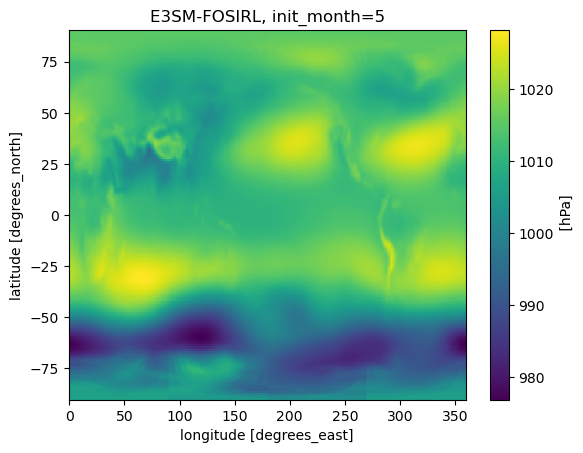

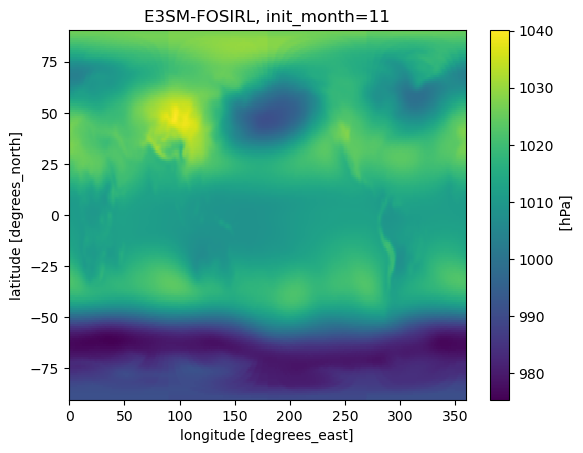

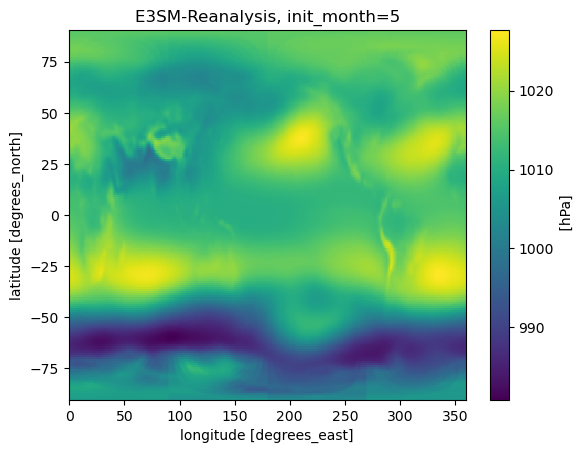

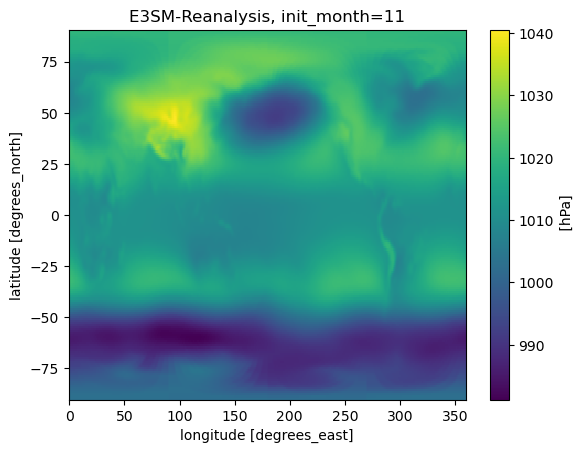

In [9]:
for case_key, by_month in e3sm_da_by_case_month.items():
    for init_month, da in by_month.items():
        da.isel(Y=0, L=0, M=0).plot()
        plt.title(f"{case_key}, init_month={init_month}")
        plt.show()




### Get Observational datasets
- Load observational datasets from the E3SM Diags archive (CMOR variables).
- Harmonize in time, variable naming, and space (regridding to a common grid).
- Provide consistent reference fields for hindcast evaluation.
- Compute OBS seasonal averages as a simple rolling mean
- Regrid to analysis grid 

In [10]:
%%time
# Load observations using the selected field configuration.
obs_dir = "/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series"
obs_name = cfg["obs_name"]
obs_var = cfg["obs_var"]
obs_map = {field: obs_var}
obs_ys = cfg["obs_ys"]
obs_ye = cfg["obs_ye"]
verbose = True

obs_chunks = {
    "time": 24,
    "lat": 90,
    "lon": 180,
}

obs_monthly = obs_access.get_monthly_data(
    obs_dir=obs_dir,
    field=field,
    field_map=obs_map,
    product=obs_name,
    start_year=obs_ys,
    end_year=obs_ye,
    chunks=obs_chunks,
    verbose=verbose,
)

# Compute OBS seasonal averages.
obs_seas = obs_access.mon_to_seas_obs(
    obs_monthly,
    var=obs_var,
    field_map=obs_map,
)

# Rechunk after rolling.
obs_seas = obs_seas.chunk(obs_chunks)

# Build regridder from Dataset, not DataArray.
regridder_obs = regrid.make_regridder(
    obs_monthly,
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

# Regrid seasonal DataArray.
try:
    obs_seas_rg = regridder_obs(
        obs_seas,
        output_chunks=obs_chunks,
    )
except TypeError:
    obs_seas_rg = regridder_obs(obs_seas)

# Rechunk after regrid and apply variable-specific unit conversion.
obs_seas_rg = obs_seas_rg.chunk(obs_chunks)
print(obs_seas_rg)

obs_seas_rg = cfg["obs_convert"](obs_seas_rg)
print(obs_seas_rg)

# Backward-compatible aliases for older exploratory cells.
if cfg["obs_name"] == "ERA5":
    obs_era5_seas_rg = obs_seas_rg
if field == "PRECT":
    obs_gpcp_seas_rg = obs_seas_rg


[OBS] Mapping field 'PSL' -> 'psl'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/ERA5/psl_197901_201912.nc
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<astype, shape=(490, 181, 360), dtype=float32, chunksize=(24, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    regrid_method:  conservative
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<mul, shape=(490, 181, 360), dtype=float32, chunksize=(24, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


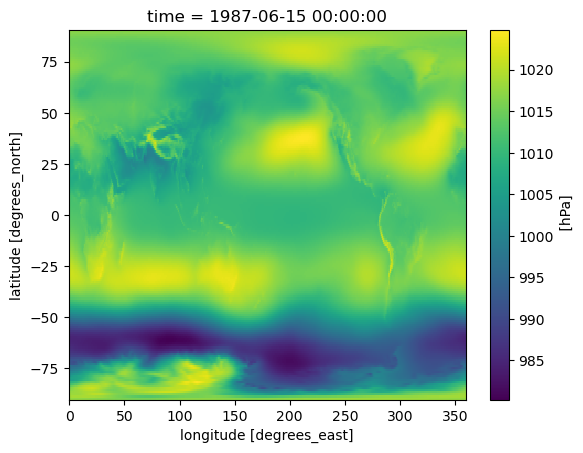

In [11]:
obs_seas_rg.isel(time=100).plot()

# Skill Analysis

In [12]:
%%time
# Valid times are captured by the E3SM regridding cell before its seasonal
# source datasets are released.
if "time_by_case_month" not in globals():
    raise RuntimeError("Run the E3SM seasonal regridding cell first.")

# Backward-compatible convenience variables for exploratory cells.
time_by_month = time_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)




CPU times: user 7 μs, sys: 1e+03 ns, total: 8 μs
Wall time: 11.9 μs


In [13]:
%%time
# Compute de-drifted anomalies from specified climatology.

anom_by_case_month = {}
clim_by_case_month = {}

for case_key in E3SM_CASES:
    anom_by_case_month[case_key] = {}
    clim_by_case_month[case_key] = {}

    for init_month in init_months:
        anom_by_case_month[case_key][init_month], clim_by_case_month[case_key][init_month] = stats.remove_drift(
            e3sm_da_by_case_month[case_key][init_month],
            time_by_case_month[case_key][init_month],
            climy0,
            climy1,
        )

# Backward-compatible convenience variables for exploratory cells.
anom_by_month = anom_by_case_month[E3SM_REFERENCE_CASE]
clim_by_month = clim_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_anom = anom_by_month.get(5)
e3smle11_anom = anom_by_month.get(11)
e3smle05_clim = clim_by_month.get(5)
e3smle11_clim = clim_by_month.get(11)




CPU times: user 49.5 ms, sys: 424 μs, total: 50 ms
Wall time: 48.9 ms


In [14]:
%%time
# Compute CESM-SMYLE benchmark de-drifted anomalies from the same climatology window.
# Recover cleanly when this cell is rerun after the former premature cleanup.
if "smyle_time_by_month" not in globals():
    smyle_time_by_month = {
        init_month: smyle_da_by_month[init_month].time.load()
        for init_month in init_months
    }

smyle_anom_by_month = {}
smyle_clim_by_month = {}

for init_month in init_months:
    smyle_anom_by_month[init_month], smyle_clim_by_month[init_month] = stats.remove_drift(
        smyle_da_by_month[init_month],
        smyle_time_by_month[init_month],
        climy0,
        climy1,
    )

smyle05_time = smyle_time_by_month.get(5)
smyle11_time = smyle_time_by_month.get(11)
smyle05_anom = smyle_anom_by_month.get(5)
smyle11_anom = smyle_anom_by_month.get(11)
smyle05_clim = smyle_clim_by_month.get(5)
smyle11_clim = smyle_clim_by_month.get(11)

# Memory cleanup: delete regridded SMYLE raw data
import gc
try:
    del smyle_da_by_month
    del smyle05_da
    del smyle11_da
except NameError:
    pass
gc.collect()


CPU times: user 384 ms, sys: 32.9 ms, total: 417 ms
Wall time: 412 ms


37

In [15]:
def check_remove_drift(da, da_time, anom, clim, climy0, climy1, name="case"):
    d1 = cftime.DatetimeNoLeap(climy0, 1, 1, 0, 0, 0)
    d2 = cftime.DatetimeNoLeap(climy1, 12, 31, 23, 59, 59)

    masked = da.where((da_time >= d1) & (da_time <= d2))
    clim_manual = masked.mean("M").mean("Y")
    anom_manual = da - clim_manual
    masked_anom = anom.where((da_time >= d1) & (da_time <= d2))

    print(f"=== {name} ===")
    print("raw dims :", da.dims, da.shape)
    print("anom dims:", anom.dims, anom.shape)
    print("clim dims:", clim.dims, clim.shape)

    xr.testing.assert_allclose(clim, clim_manual)
    xr.testing.assert_allclose(anom, anom_manual)
    print("manual reconstruction: PASS")

    resid = masked_anom.mean(("Y", "M"))
    print("max abs masked anomaly mean:", float(abs(resid).max(skipna=True)))

    nvalid = masked.notnull().sum(("Y", "M"))
    print("min valid samples per (L,lat,lon):", int(nvalid.min(skipna=True)))
    print("max valid samples per (L,lat,lon):", int(nvalid.max(skipna=True)))

    print("missing clim cells by lead:")
    print(clim.isnull().sum(("lat", "lon")))

for case_key in E3SM_CASES:
    for init_month in init_months:
        check_remove_drift(
            e3sm_da_by_case_month[case_key][init_month],
            time_by_case_month[case_key][init_month],
            anom_by_case_month[case_key][init_month],
            clim_by_case_month[case_key][init_month],
            climy0,
            climy1,
            f"{case_key}, init_month={init_month}",
        )

# Validation is the final consumer of the regridded raw E3SM data.
import gc
try:
    del e3sm_da_by_case_month
    del e3smle_da_by_month
    del e3smle05_da
    del e3smle11_da
except NameError:
    pass
gc.collect()


=== E3SM-FOSIRL, init_month=5 ===
raw dims : ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
anom dims: ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
clim dims: ('L', 'lat', 'lon') (8, 181, 360)
manual reconstruction: PASS
max abs masked anomaly mean: 0.00020365396630950272
min valid samples per (L,lat,lon): 0
max valid samples per (L,lat,lon): 300
missing clim cells by lead:
<xarray.DataArray (L: 8)> Size: 64B
dask.array<sum-aggregate, shape=(8,), dtype=int64, chunksize=(8,), chunktype=numpy.ndarray>
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Attributes:
    regrid_method:  conservative
    units:          hPa
=== E3SM-FOSIRL, init_month=11 ===
raw dims : ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
anom dims: ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
clim dims: ('L', 'lat', 'lon') (8, 181, 360)
manual reconstruction: PASS
max abs masked anomaly mean: 0.00019846949726343155
min valid samples per (L,lat,lon): 0
max valid samples per (L,lat,l

2959

In [16]:
%%time
# Compute and save E3SM skill data separately for each case/init month.
# Files are stored under <case>/leadtime_acc/skill/atm/<field>/.
e3smle_skill_dir = None

# False reuses existing skill NetCDF files; set True only for intentional regeneration.
force_compute = False
detrend = False

skill_chunk_model = {
    "Y": -1,
    "L": 8,
    "M": 2,
    "lat": 45,
    "lon": 90,
}

skill_chunk_obs = {
    "time": -1,
    "lat": 45,
    "lon": 90,
}

clim_start = cftime.DatetimeNoLeap(climy0, 1, 1)
clim_end = cftime.DatetimeNoLeap(climy1, 12, 31)

skill_by_case_month = {}
obs_skill = obs_seas_rg.chunk(skill_chunk_obs)

for case_key, case_info in E3SM_CASES.items():
    cache_tag = case_info["cache_tag"]
    skill_dir = e3sm_leadtime_dir(case_info, "skill", field)
    skill_dir.mkdir(parents=True, exist_ok=True)
    skill_by_case_month[case_key] = {}

    for init_month in init_months:
        if detrend:
            outname = f"{cache_tag}{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
        else:
            outname = f"{cache_tag}{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

        outfile = skill_dir / outname

        if os.path.exists(outfile) and not force_compute:
            skill_ds = xr.open_dataset(outfile).load()
        else:
            if force_compute and os.path.exists(outfile):
                os.remove(outfile)

            model_anom = anom_by_case_month[case_key][init_month].chunk(skill_chunk_model)
            model_time = time_by_case_month[case_key][init_month]

            skill = stats.compute_skill_seasonal(
                model_anom,
                model_time,
                obs_skill,
                clim_start,
                clim_end,
                1,
                8,
                resamp=0,
                detrend=detrend,
            )

            skill_ds = xr.Dataset({
                "corr": skill.corr,
                "pval": skill.pval,
                "rmse": skill.rmse,
                "msss": skill.msss,
                "rpc": skill.rpc,
                "sig_obs": skill.sig_obs,
                "sig_sig": skill.sig_sig,
                "sig_tot": skill.sig_tot,
                "s2t": skill.s2t,
            }).compute()

            skill_ds.to_netcdf(outfile)

        skill_by_case_month[case_key][init_month] = skill_ds

        print(outfile)
        print(skill_ds)

# Backward-compatible aliases.
skill_by_month = skill_by_case_month[E3SM_REFERENCE_CASE]
skill05_ds = skill_by_month.get(5)
skill11_ds = skill_by_month.get(11)




/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/PSL/JRA55_FOSIRL05_PSL_skill_clim_1981_2010.nc
<xarray.Dataset> Size: 23MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    corr     (L, lat, lon) float32 2MB 0.2527 0.251 0.2508 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.1259 0.1285 0.1288 ... nan nan nan
    rmse     (L, lat, lon) float32 2MB 0.991 0.9922 0.9923 ... nan nan nan
    msss     (L, lat, lon) float32 2MB 0.01792 0.01562 0.01542 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.6722 0.6696 0.6691 ... nan nan nan
    sig_obs  (L, lat, lon) float32 2MB 3.753 3.753 3.752 ... 4.524 4.525 4.526
    sig_sig  (L, lat, lon) float32 2MB 1.661 1.668 1.668 1.668 ... nan nan nan
    sig_tot  (L, lat, lon) float32 2MB 4.

In [17]:
%%time
# Compute and save CESM-SMYLE benchmark skill with the same observations/settings.
smyle_skill_outdir = smyle_leadtime_dir("skill", field)
os.makedirs(smyle_skill_outdir, exist_ok=True)

smyle_skill_by_month = {}
obs_skill = obs_skill.chunk(skill_chunk_obs)

for init_month in init_months:
    if detrend:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    outfile = os.path.join(smyle_skill_outdir, outname)

    if os.path.exists(outfile) and not force_compute:
        skill_ds = xr.open_dataset(outfile).load()
    else:
        if force_compute and os.path.exists(outfile):
            os.remove(outfile)

        model_anom = smyle_anom_by_month[init_month].chunk(skill_chunk_model)
        model_time = smyle_time_by_month[init_month]

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_skill,
            clim_start,
            clim_end,
            1,
            8,
            resamp=0,
            detrend=detrend,
        )

        skill_ds = xr.Dataset({
            "corr": skill.corr,
            "pval": skill.pval,
            "rmse": skill.rmse,
            "msss": skill.msss,
            "rpc": skill.rpc,
            "sig_obs": skill.sig_obs,
            "sig_sig": skill.sig_sig,
            "sig_tot": skill.sig_tot,
            "s2t": skill.s2t,
        }).compute()

        skill_ds.to_netcdf(outfile)

    smyle_skill_by_month[init_month] = skill_ds
    print(outfile)
    print(skill_ds)

smyle05_skill_ds = smyle_skill_by_month.get(5)
smyle11_skill_ds = smyle_skill_by_month.get(11)

skill_delta_by_case_month = {
    case_key: {
        init_month: skill_by_case_month[case_key][init_month].corr - smyle_skill_by_month[init_month].corr
        for init_month in init_months
    }
    for case_key in E3SM_CASES
}

# Backward-compatible alias.
skill_delta_by_month = skill_delta_by_case_month[E3SM_REFERENCE_CASE]




/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/skill/PSL/BSMYLE05_PSL_skill_clim_1981_2010.nc
<xarray.Dataset> Size: 23MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    corr     (L, lat, lon) float32 2MB 0.2891 0.2892 0.2893 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.07423 0.07412 0.07408 ... nan nan nan
    rmse     (L, lat, lon) float32 2MB 0.9594 0.9594 0.9594 ... nan nan nan
    msss     (L, lat, lon) float32 2MB 0.07948 0.07954 0.07955 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.9546 0.9551 0.9552 ... nan nan nan
    sig_obs  (L, lat, lon) float32 2MB 3.753 3.753 3.752 ... 4.524 4.525 4.526
    sig_sig  (L, lat, lon) float32 2MB 1.115 1.115 1.115 1.115 ... nan nan nan
    sig_tot  (L, lat, lon) float32 2MB 3.681

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 45.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/skill/PSL/BSMYLE11_PSL_skill_clim_1981_2010.nc
<xarray.Dataset> Size: 23MB
Dimensions:  (lat: 181, lon: 360, L: 8)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Data variables:
    corr     (L, lat, lon) float32 2MB 0.06161 0.06117 0.06093 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.7133 0.7152 0.7163 ... nan nan nan
    rmse     (L, lat, lon) float32 2MB 1.129 1.13 1.13 1.13 ... nan nan nan nan
    msss     (L, lat, lon) float32 2MB -0.2757 -0.2759 -0.2761 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.127 0.1262 0.1257 ... nan nan nan
    sig_obs  (L, lat, lon) float32 2MB 3.415 3.415 3.415 ... 2.895 2.895 2.896
    sig_sig  (L, lat, lon) float32 2MB 1.872 1.871 1.87 1.87 ... nan nan nan nan
    sig_tot  (L, lat, lon) float32 2MB 

### Final RMSE Plot: BSMYLE vs E3SMLE
- Reads saved skill files for both BSMYLE/CESM-SMYLE and E3SMLE.
- Plots each initialization month as paired columns: CESM-SMYLE on the left, E3SMLE on the right.
- Adds light latitude-longitude gridlines with labels only on the outer plot edges.


2026-07-20 01:57:54,989 - distributed.nanny - WARNING - Restarting worker
2026-07-20 01:57:54,993 - distributed.nanny - WARNING - Restarting worker
2026-07-20 01:57:54,995 - distributed.nanny - WARNING - Restarting worker
2026-07-20 01:57:55,134 - distributed.nanny - WARNING - Restarting worker


=== Sanity check: data range ===
CESM-SMYLE init_month=5 RMSE min/max: 0.2071152776479721 6.317253589630127
CESM-SMYLE init_month=11 RMSE min/max: 0.256519615650177 6.788667678833008
E3SM-FOSIRL init_month=5 RMSE min/max: 0.26197224855422974 6.958061695098877
E3SM-FOSIRL init_month=11 RMSE min/max: 0.2691270411014557 6.6874680519104
E3SM-Reanalysis init_month=5 RMSE min/max: 0.23962467908859253 6.719336032867432
E3SM-Reanalysis init_month=11 RMSE min/max: 0.23805280029773712 6.769644260406494
working on figure: fig_psl_multi_e3sm_rmse_skill_map.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_multi_e3sm_rmse_skill_map.png


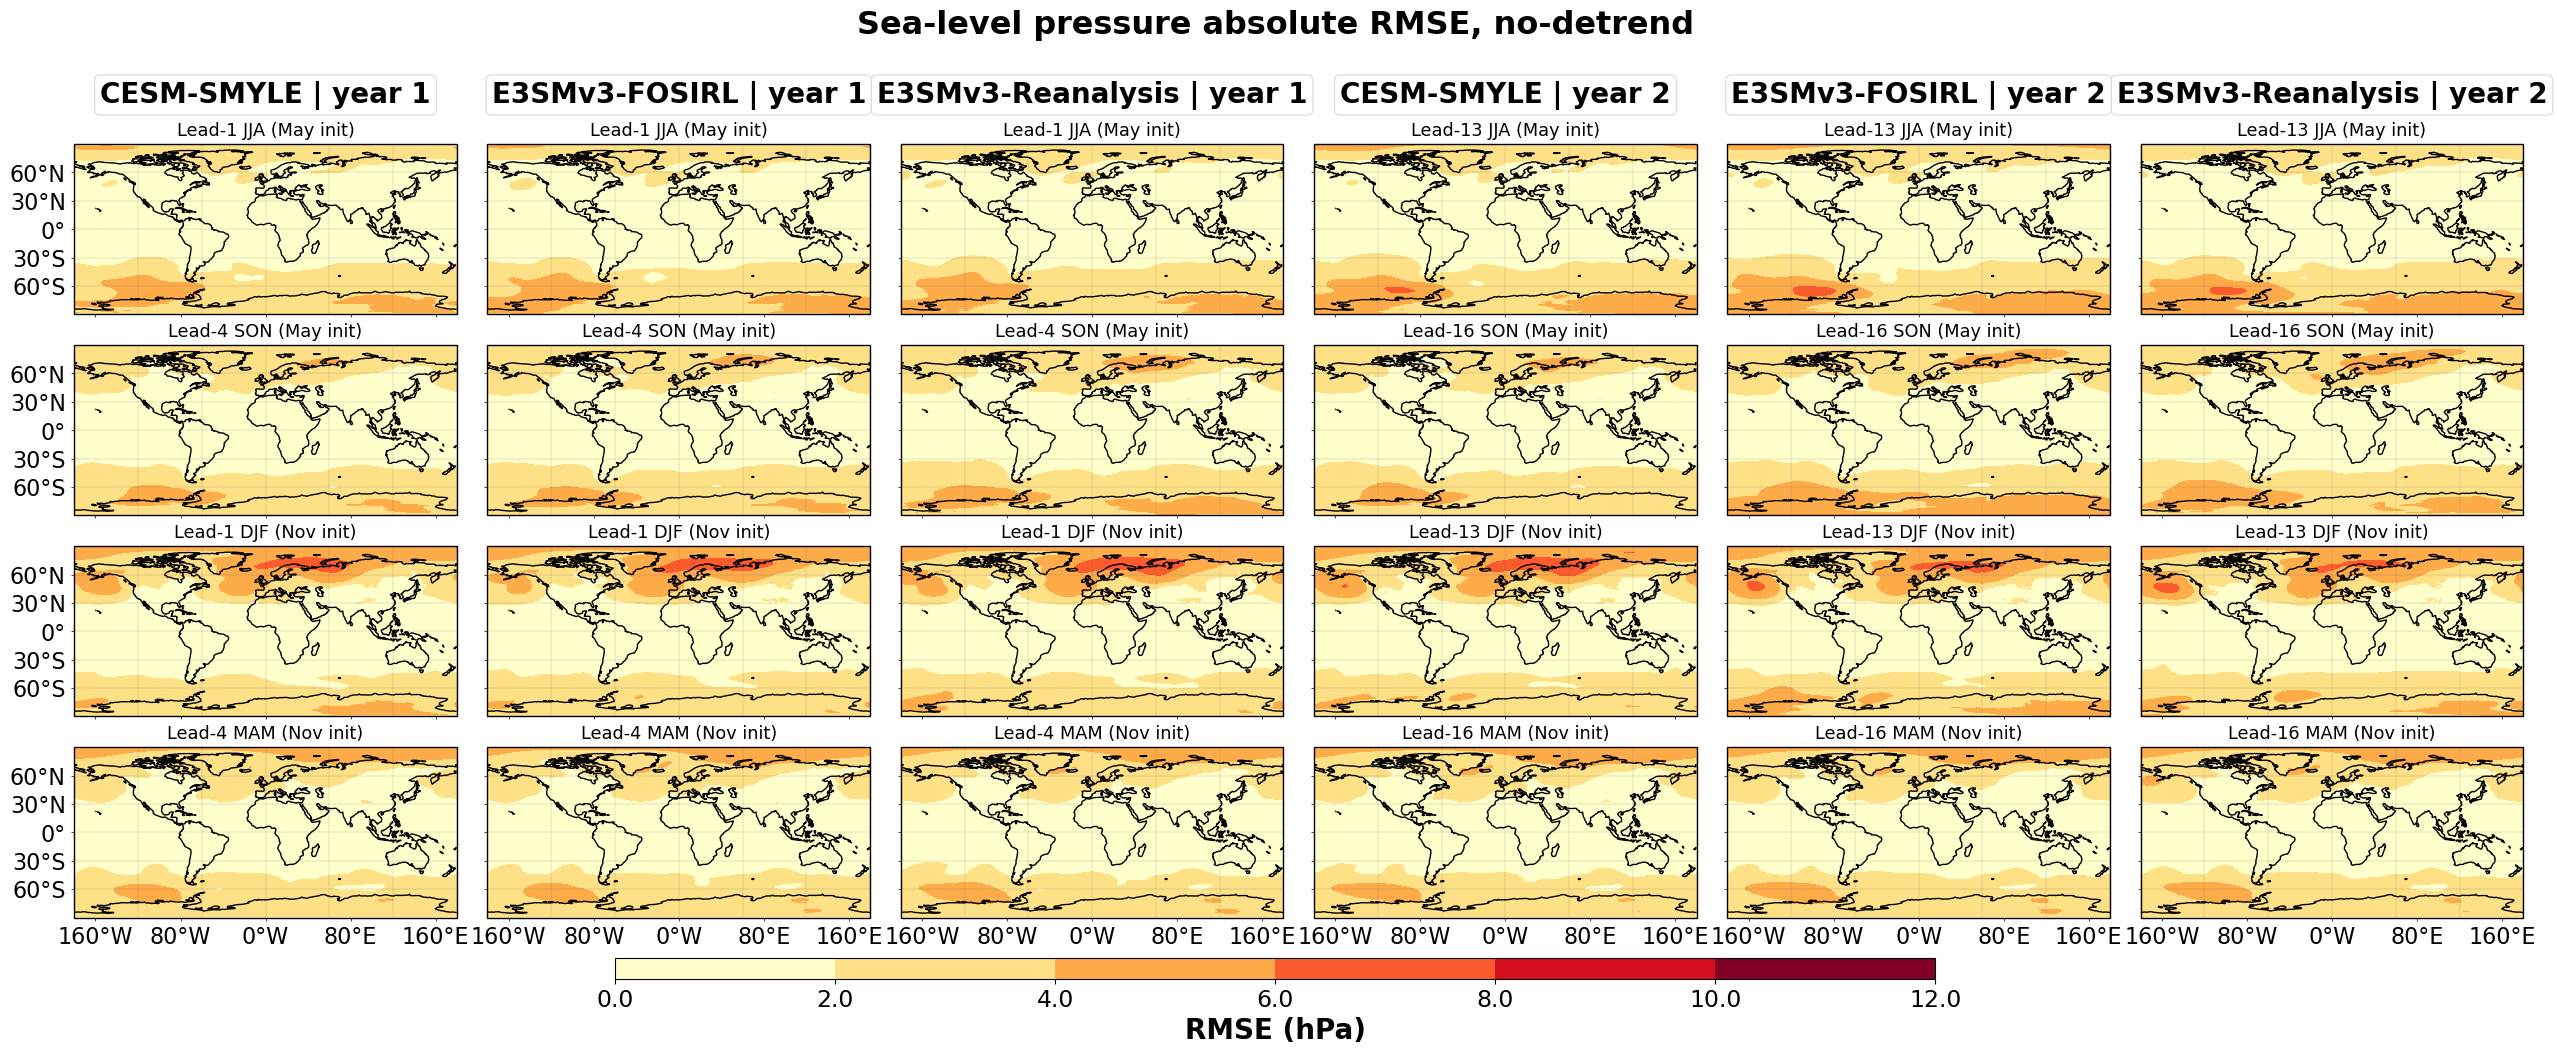

CPU times: user 17.5 s, sys: 1.33 s, total: 18.8 s
Wall time: 20 s


In [18]:
%%time

# Restart Dask workers to clean up memory before starting the heavy Monte Carlo iterations
try:
    client.restart()
except:
    pass
# Read saved CESM-SMYLE and multi-case E3SM skill data and plot side by side.
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.offsetbox import AnchoredText
import matplotlib.ticker as mticker

# ---------------------------------------------------------------------------
# User-adjustable final-plot setup
# ---------------------------------------------------------------------------
e3smle_skill_dir = None
smyle_skill_dir = str(smyle_leadtime_dir("skill", field))

metric = "RMSE"
metric_units = cfg.get("units", "")
metric_label = f"{metric} ({metric_units})" if metric_units else metric
# Standalone fallback, matching the multi-case setup cell above.
E3SM_CASES = globals().get("E3SM_CASES", {
    "E3SM-FOSIRL": {"cache_tag": "JRA55_FOSIRL", "display_name": "E3SMv3-FOSIRL"},
    "E3SM-Reanalysis": {"cache_tag": "Reanalysis", "display_name": "E3SMv3-Reanalysis"},
    "E3SM-4DEnVarOcn": {"cache_tag": "4DEnVarOcn", "display_name": "E3SMv3-4DEnVarOcn"},
})
E3SM_REFERENCE_CASE = globals().get("E3SM_REFERENCE_CASE", "E3SM-FOSIRL")

model_order = ["CESM-SMYLE"] + list(E3SM_CASES)
model_display_name = {"CESM-SMYLE": "CESM-SMYLE"}
model_display_name.update({
    case_key: case_info.get("display_name", case_key)
    for case_key, case_info in E3SM_CASES.items()
})
# Files retain rolling-window coordinates 3, 6, ..., 24. Figures use the
# original seasonal convention: lead 1 = months 1-3, lead 4 = months 4-6.
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}

sigon = False
siglvl = 0.1
mask_negacc = False

# Single font-size control for the full multi-panel figure.
fontz = 20
panel_title_size = fontz
lead_label_size = fontz * 0.85
lat_lon_label_size = fontz * 0.8
colorbar_label_size = fontz
colorbar_tick_size = fontz * 0.85
suptitle_size = fontz * 1.15
fweight = 'bold'

# Plot style/layout controls.
figfmt = "png"
fig_col_width = 4.4
fig_row_height = 2.55
projection = ccrs.PlateCarree()
suptitle_y = 0.995
tight_layout_rect = [0.015, 0.13, 0.985, 0.945]
bottom = 0.105
hspace = 0.18
wspace = 0.08

cmap = "YlOrRd"
coff = 0.5
# Use the absolute-RMSE colorbar selected with `field` above.
colorbar_levels = rmse_levels
colorbar_ticks = rmse_ticks
colorbar_tick_decimals = rmse_decimals

colorbar_axes = [0.25, 0.045, 0.5, 0.02]
colorbar_orientation = 'horizontal'
dpi = 300

lon_ticks = [-160, -80, 0, 80, 160]
lat_ticks = [-60, -30, 0, 30, 60]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 1.0
gridline_width = 0.35
gridline_color = "0.35"
gridline_alpha = 0.35
gridline_style = "-"

lead_label_loc = "lower right"
lead_label_pad = 0.25
lead_label_borderpad = 0.35
lead_label_bbox = dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="lightgray",
    alpha=0.85,
    linewidth=0.8,
)

skill_by_model = {model: {} for model in model_order}

for init_month in init_months:
    if detrend:
        smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    skill_by_model["CESM-SMYLE"][init_month] = xr.open_dataset(
        os.path.join(smyle_skill_dir, smyle_name)
    ).load()

    for case_key, case_info in E3SM_CASES.items():
        cache_tag = case_info.get("cache_tag", case_key.replace("E3SM-", ""))
        if detrend:
            e3sm_name = f"{cache_tag}{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
        else:
            e3sm_name = f"{cache_tag}{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

        e3sm_path = e3sm_leadtime_dir(case_info, "skill", field) / e3sm_name
        skill_by_model[case_key][init_month] = xr.open_dataset(e3sm_path).load()

# Keep the old variable names available for exploratory cells below/above.
skill_by_case_month = {
    case_key: skill_by_model[case_key]
    for case_key in E3SM_CASES
}
skill_by_month = skill_by_model[E3SM_REFERENCE_CASE]
smyle_skill_by_month = skill_by_model["CESM-SMYLE"]

def seasonal_label(init_month, lead):
    # Native lead is the number of months from initialization through the
    # target season; its center month is therefore init + lead - 1.
    center_month = ((init_month + lead - 2) % 12) + 1
    return season_names[((center_month % 12) // 3)]


def lead_label(init_month, lead):
    display_lead = lead - 2
    init_label = init_month_names.get(init_month, f"{init_month:02d}").title()
    return f"Lead-{display_lead} {seasonal_label(init_month, lead)} ({init_label} init)"


def add_lead_label(ax, text):
    label = AnchoredText(
        text,
        loc=lead_label_loc,
        prop=dict(size=lead_label_size, weight=fweight, family="monospace"),
        frameon=True,
        pad=lead_label_pad,
        borderpad=lead_label_borderpad,
    )
    label.patch.set(**lead_label_bbox)
    ax.add_artist(label)


def set_map_axis_linewidth(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(map_axis_linewidth)
    if hasattr(ax, "outline_patch"):
        ax.outline_patch.set_linewidth(map_axis_linewidth)


def add_lat_lon_labels(ax, row, col, nrows, ncols):
    # Keep labels on the outer edges so the multi-panel plot stays readable.
    set_map_axis_linewidth(ax)
    ax.set_xticks(lon_ticks, crs=projection)
    ax.set_yticks(lat_ticks, crs=projection)
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(
        labelsize=lat_lon_label_size,
        length=lat_lon_tick_length,
        width=lat_lon_tick_width,
        top=False,
        right=False,
        labelbottom=(row == nrows - 1),
        labelleft=(col == 0),
    )
    ax.gridlines(
        crs=projection,
        linewidth=gridline_width,
        color=gridline_color,
        alpha=gridline_alpha,
        linestyle=gridline_style,
        draw_labels=False,
    )

skill_plot_by_model = skill_by_model

# Organize by verification season so forecast-year growth is not confused
# with the large seasonal cycle in absolute temperature RMSE.
season_comparisons = [
    {"season": "JJA", "init_month": 5, "year_leads": [3, 15]},
    {"season": "SON", "init_month": 5, "year_leads": [6, 18]},
    {"season": "DJF", "init_month": 11, "year_leads": [3, 15]},
    {"season": "MAM", "init_month": 11, "year_leads": [6, 18]},
]
plot_columns = (
    [(model, 0) for model in model_order]
    + [(model, 1) for model in model_order]
)

for spec in season_comparisons:
    init_month = spec["init_month"]
    for model in model_order:
        if init_month not in skill_plot_by_model[model]:
            raise KeyError(f"Missing {model} skill data for init_month={init_month}.")
        available = np.asarray(skill_plot_by_model[model][init_month].L.values, dtype=int)
        missing = [lead for lead in spec["year_leads"] if lead not in available]
        if missing:
            raise ValueError(
                f"Missing leads {missing} for {model}, init_month={init_month}; "
                f"available={available.tolist()}"
            )

nrows = len(season_comparisons)
ncols = len(plot_columns)

if detrend:
    subtitle = f"{cfg['plot_name']} absolute {metric}, linear-detrend"
    trendstr = "wt_detrend"
else:
    subtitle = f"{cfg['plot_name']} absolute {metric}, no-detrend"
    trendstr = "wo_detrend"

def absolute_rmse(skill_plot):
    if "rmse" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'rmse' in the skill dataset.")
    if "sig_obs" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'sig_obs' to undo RMSE normalization.")

    rmse_abs = skill_plot.rmse * skill_plot.sig_obs
    rmse_abs.attrs["long_name"] = "RMSE"
    rmse_abs.attrs["units"] = metric_units
    return rmse_abs


rmse_by_model = {}
for model in model_order:
    rmse_by_model[model] = {}
    for init_month in sorted({spec["init_month"] for spec in season_comparisons}):
        skill_plot = skill_plot_by_model[model][init_month]
        rmse = absolute_rmse(skill_plot)

        rmse_by_model[model][init_month] = rmse

sigstr = "wo_sigmask"

if colorbar_levels.ndim != 1 or colorbar_levels.size < 2:
    raise ValueError("colorbar_levels must contain at least two values")
level_steps = np.diff(colorbar_levels)
if np.any(level_steps <= 0) or not np.allclose(level_steps, level_steps[0]):
    raise ValueError("colorbar_levels must be strictly increasing and uniformly spaced")
cmin = float(colorbar_levels[0])
cmax = float(colorbar_levels[-1])
ci = float(level_steps[0])

print("=== Sanity check: data range ===")
for model in model_order:
    for init_month, rmse in rmse_by_model[model].items():
        print(
            f"{model} init_month={init_month} RMSE min/max:",
            float(rmse.min(skipna=True)),
            float(rmse.max(skipna=True)),
        )

figname = figure_filename(field, "multi_e3sm", "rmse_skill_map", ext=figfmt)

print(f"working on figure: {figname}")

fig = plt.figure(figsize=(fig_col_width * ncols, fig_row_height * nrows))
fig.suptitle(subtitle, fontsize=suptitle_size, fontweight=fweight, y=suptitle_y)
proj = projection
cntr = None
top_row_axes = {}
axes_by_column = {j: [] for j in range(ncols)}

for i, spec in enumerate(season_comparisons):
    season = spec["season"]
    init_month = spec["init_month"]
    init_label = init_month_names.get(init_month, f"{init_month:02d}")

    for j, (model, year_index) in enumerate(plot_columns):
        lead = spec["year_leads"][year_index]
        forecast_year = year_index + 1
        skill_plot = skill_plot_by_model[model][init_month]
        subplot = i * ncols + j + 1
        model_name = model_display_name.get(model, model)
        title = lead_label(init_month, lead)

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            rmse_by_model[model][init_month].sel(L=lead),
            skill_plot.lon,
            skill_plot.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap=cmap, cutoff=coff,
            fontsize=lead_label_size * 0.75,
        )
        axes_by_column[j].append(ax)
        if i == 0:
            top_row_axes[j] = ax
        add_lat_lon_labels(ax, i, j, nrows, ncols)

fig.tight_layout(rect=tight_layout_rect, h_pad=0.65, w_pad=0.35)
fig.subplots_adjust(bottom=bottom, hspace=hspace, wspace=wspace)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
title_tops = [
    ax.title.get_window_extent(renderer=renderer)
    .transformed(fig.transFigure.inverted()).y1
    for ax in top_row_axes.values()
]
column_header_y = min(0.952, max(title_tops) + 0.012)
for j, (model, year_index) in enumerate(plot_columns):
    model_name = model_display_name.get(model, model)
    fig.text(
        0.5 * (top_row_axes[j].get_position().x0 + top_row_axes[j].get_position().x1),
        column_header_y,
        f"{model_name} | year {year_index + 1}",
        ha="center",
        va="bottom",
        fontsize=panel_title_size,
        fontweight=fweight,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
    )
cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
cbar.set_ticks(colorbar_ticks)
tick_format = f"%.{colorbar_tick_decimals}f"
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(tick_format))
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="leadtime_rmse",
    title=f"Leadtime RMSE: {field}",
    caption="RMSE skill vs lead month, global",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()



=== CONUS lead selection ===
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_multi_e3sm_rmse_skill_map_conus.png


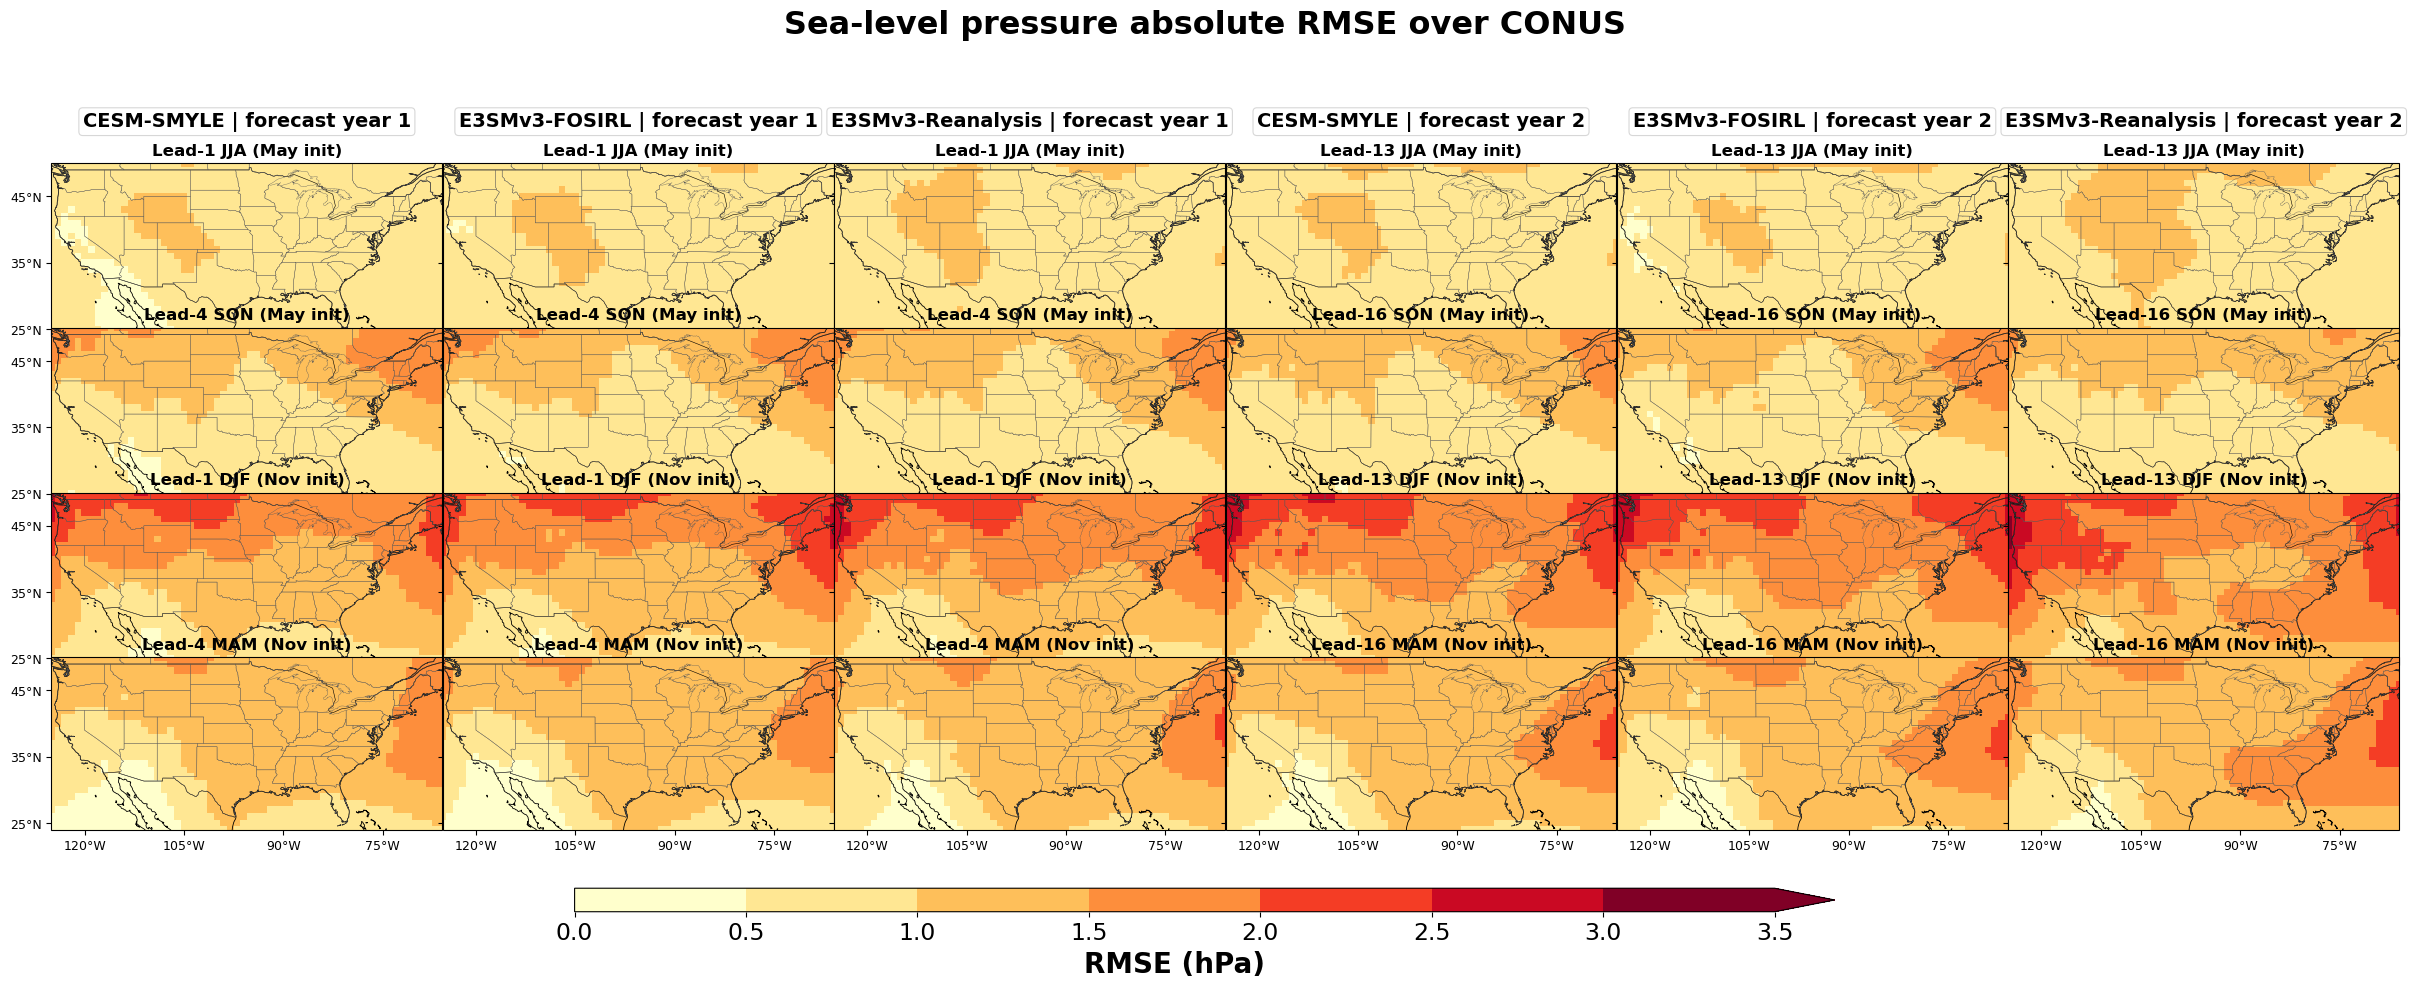

CPU times: user 6.73 s, sys: 709 ms, total: 7.44 s
Wall time: 6.98 s


In [19]:
%%time
# CONUS absolute RMSE growth for the same verification seasons.
# Run after the global absolute-RMSE plotting cell above so skill_plot_by_model
# and absolute_rmse are already defined.
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm

# Import or restore E3SM configuration
E3SM_CASES = globals().get("E3SM_CASES", {
    "E3SM-FOSIRL": {"cache_tag": "JRA55_FOSIRL", "display_name": "E3SMv3-FOSIRL"},
    "E3SM-Reanalysis": {"cache_tag": "Reanalysis", "display_name": "E3SMv3-Reanalysis"},
    "E3SM-4DEnVarOcn": {"cache_tag": "4DEnVarOcn", "display_name": "E3SMv3-4DEnVarOcn"},
})
E3SM_REFERENCE_CASE = globals().get("E3SM_REFERENCE_CASE", "E3SM-FOSIRL")

conus_models = ["CESM-SMYLE"] + list(E3SM_CASES)
conus_detrend = False  # absolute RMSE should usually show non-detrended model error
# Rows are verification seasons; columns compare both models in years 1 and 2.
conus_seasons = [
    ("JJA", 5, [3, 15]),
    ("SON", 5, [6, 18]),
    ("DJF", 11, [3, 15]),
    ("MAM", 11, [6, 18]),
]
conus_extent = [-125, -66, 24, 50]
conus_cmap = "YlOrRd"
# CONUS variability is much smaller than the global range, especially for PSL.
# Use a regional scale so meaningful spatial and model differences remain visible.
CONUS_RMSE_COLORBAR_CONFIG = {
    "TREFHT": {"levels": np.arange(0.0, 3.0 + 0.5, 0.5), "ticks": np.arange(0.0, 3.0 + 0.5, 0.5), "decimals": 1},
    "PRECT": {"levels": np.arange(0.0, 3.0 + 0.5, 0.5), "ticks": np.arange(0.0, 3.0 + 0.5, 0.5), "decimals": 1},
    "PSL": {"levels": np.arange(0.0, 3.5 + 0.5, 0.5), "ticks": np.arange(0.0, 3.5 + 0.5, 0.5), "decimals": 1},
}
conus_colorbar_config = CONUS_RMSE_COLORBAR_CONFIG[field]
conus_colorbar_levels = np.asarray(conus_colorbar_config["levels"], dtype=float)
conus_colorbar_ticks = np.asarray(conus_colorbar_config["ticks"], dtype=float)
conus_colorbar_tick_decimals = int(conus_colorbar_config["decimals"])
conus_col_width = 4.2
conus_row_height = 2.35
conus_panel_title_size = 12
conus_column_header_size = 14
conus_tick_size = 9
conus_hspace = 0.16
conus_wspace = 0.04

# Defaults needed if this cell is run without the global RMSE map cell above.
e3smle_skill_dir = globals().get("e3smle_skill_dir", str(E3SMLE_OUTDIR))
smyle_skill_dir = globals().get("smyle_skill_dir", str(smyle_leadtime_dir("skill", field)))
metric = globals().get("metric", "RMSE")
metric_units = globals().get("metric_units", cfg.get("units", ""))
metric_label = globals().get("metric_label", f"{metric} ({metric_units})" if metric_units else metric)
figfmt = globals().get("figfmt", "png")
dpi = globals().get("dpi", 300)
fweight = globals().get("fweight", "bold")
suptitle_size = globals().get("suptitle_size", 22)
colorbar_label_size = globals().get("colorbar_label_size", 18)
colorbar_tick_size = globals().get("colorbar_tick_size", 15)


def require_available_lead(da, target_lead):
    available = np.asarray(da.L.values, dtype=int)
    if target_lead not in available:
        raise ValueError(
            f"Requested lead {target_lead} is unavailable; native leads are {available.tolist()}."
        )
    return int(target_lead)


def subset_conus(da):
    if float(da.lon.max()) > 180:
        da = da.sel(lon=slice(235, 294))
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
        da = da.sortby("lon")
    else:
        da = da.sel(lon=slice(conus_extent[0], conus_extent[1]))

    lat_slice = slice(conus_extent[2], conus_extent[3])
    if da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        lat_slice = slice(conus_extent[3], conus_extent[2])
    return da.sel(lat=lat_slice)


def add_conus_features(ax):
    for feature, kwargs in [
        (cfeature.COASTLINE, {"linewidth": 0.6}),
        (cfeature.BORDERS, {"linewidth": 0.4}),
        (cfeature.STATES, {"linewidth": 0.25, "edgecolor": "0.35"}),
    ]:
        try:
            ax.add_feature(feature, **kwargs)
        except Exception as err:
            print(f"Skipping Cartopy feature {feature}: {err}")


def absolute_rmse_from_skill(skill_plot):
    if "rmse" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'rmse' in the skill dataset.")
    if "sig_obs" not in skill_plot:
        raise KeyError("Absolute RMSE requires 'sig_obs' to undo RMSE normalization.")

    rmse_abs = skill_plot.rmse * skill_plot.sig_obs
    rmse_abs.attrs["long_name"] = "RMSE"
    rmse_abs.attrs["units"] = metric_units
    return rmse_abs


if "absolute_rmse" not in globals():
    absolute_rmse = absolute_rmse_from_skill

if "skill_plot_by_model" not in globals():
    print("skill_plot_by_model not found; loading saved skill datasets for CONUS plot.")
    skill_by_model = {model: {} for model in conus_models}
    for init_month in init_months:
        if conus_detrend:
            smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
        else:
            smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

        smyle_path = os.path.join(smyle_skill_dir, smyle_name)
        if not os.path.exists(smyle_path):
            raise FileNotFoundError(
                "Missing non-detrended RMSE skill file for the CONUS plot.\n"
                f"Missing:\n{smyle_path}"
            )
        skill_by_model["CESM-SMYLE"][init_month] = xr.open_dataset(smyle_path).load()

        for case_key, case_info in E3SM_CASES.items():
            cache_tag = case_info.get("cache_tag", case_key.replace("E3SM-", ""))
            if conus_detrend:
                e3sm_name = f"{cache_tag}{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
            else:
                e3sm_name = f"{cache_tag}{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"
            e3sm_path = e3sm_leadtime_dir(case_info, "skill", field) / e3sm_name
            if not os.path.exists(e3sm_path):
                raise FileNotFoundError(
                    "Missing non-detrended E3SM RMSE skill file for the CONUS plot.\n"
                    f"Missing:\n{e3sm_path}"
                )
            skill_by_model[case_key][init_month] = xr.open_dataset(e3sm_path).load()

    skill_plot_by_model = skill_by_model


conus_fields = {model: {} for model in conus_models}
conus_actual_leads = {model: {} for model in conus_models}
for model in conus_models:
    for season_name, init_month, season_leads in conus_seasons:
        if init_month not in skill_plot_by_model[model]:
            raise KeyError(f"Missing {model} skill data for init_month={init_month}.")
        rmse_abs = absolute_rmse(skill_plot_by_model[model][init_month])
        conus_fields[model][season_name] = {}
        conus_actual_leads[model][season_name] = {}
        for target_lead in season_leads:
            actual_lead = require_available_lead(rmse_abs, target_lead)
            conus_actual_leads[model][season_name][target_lead] = actual_lead
            conus_fields[model][season_name][target_lead] = subset_conus(
                rmse_abs.sel(L=actual_lead)
            )

if conus_colorbar_levels.ndim != 1 or conus_colorbar_levels.size < 2:
    raise ValueError("conus_colorbar_levels must contain at least two values")
conus_level_steps = np.diff(conus_colorbar_levels)
if np.any(conus_level_steps <= 0):
    raise ValueError("conus_colorbar_levels must be strictly increasing")
conus_cmap_obj = plt.get_cmap(conus_cmap)
conus_norm = BoundaryNorm(conus_colorbar_levels, conus_cmap_obj.N, clip=False)

print("=== CONUS lead selection ===")
for model in conus_models:
    for season_name in conus_fields[model]:
        for target_lead, actual_lead in conus_actual_leads[model][season_name].items():
            if actual_lead != target_lead:
                print(
                    f"{model} {season_name}: requested lead {target_lead}, "
                    f"using available seasonal lead {actual_lead}"
                )

conus_plot_columns = (
    [(model, 0) for model in conus_models]
    + [(model, 1) for model in conus_models]
)
nrows = len(conus_seasons)
ncols = len(conus_plot_columns)
conus_figsize = (conus_col_width * ncols, conus_row_height * nrows)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=conus_figsize,
    subplot_kw={"projection": ccrs.PlateCarree()},
    squeeze=False,
)

cntr = None
top_row_axes = {}
for i, (season_name, init_month, season_leads) in enumerate(conus_seasons):
    for j, (model, year_index) in enumerate(conus_plot_columns):
        target_lead = season_leads[year_index]
        ax = axes[i, j]
        da = conus_fields[model][season_name][target_lead]
        actual_lead = conus_actual_leads[model][season_name][target_lead]
        cntr = ax.pcolormesh(
            da.lon,
            da.lat,
            da,
            shading="nearest",
            cmap=conus_cmap_obj,
            norm=conus_norm,
            rasterized=True,
            transform=ccrs.PlateCarree(),
        )
        ax.set_extent(conus_extent, crs=ccrs.PlateCarree())
        add_conus_features(ax)
        panel_title = lead_label(init_month, actual_lead)
        ax.set_title(panel_title, fontsize=conus_panel_title_size, fontweight=fweight)
        if i == 0:
            top_row_axes[j] = ax
        ax.set_xticks([-120, -105, -90, -75], crs=ccrs.PlateCarree())
        ax.set_yticks([25, 35, 45], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(
            labelsize=conus_tick_size,
            labelbottom=(i == nrows - 1),
            labelleft=(j == 0),
            top=False,
            right=False,
        )

# Finish the figure with unambiguous model/year headers and a shared colorbar.
model_display_name = globals().get("model_display_name", {
    "CESM-SMYLE": "CESM-SMYLE",
    **{case_key: case_info.get("display_name", case_key) for case_key, case_info in E3SM_CASES.items()},
})
conus_subtitle = f"{cfg['plot_name']} absolute RMSE over CONUS"
fig.suptitle(conus_subtitle, fontsize=suptitle_size, fontweight=fweight, y=0.995)
fig.tight_layout(rect=[0.02, 0.10, 0.98, 0.90], h_pad=conus_hspace, w_pad=conus_wspace)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
title_tops = [
    ax.title.get_window_extent(renderer=renderer)
    .transformed(fig.transFigure.inverted()).y1
    for ax in top_row_axes.values()
]
column_header_y = min(0.955, max(title_tops) + 0.012)
for j, (model, year_index) in enumerate(conus_plot_columns):
    ax = top_row_axes[j]
    fig.text(
        0.5 * (ax.get_position().x0 + ax.get_position().x1),
        column_header_y,
        f"{model_display_name.get(model, model)} | forecast year {year_index + 1}",
        ha="center",
        va="bottom",
        fontsize=conus_column_header_size,
        fontweight=fweight,
        bbox=dict(
            boxstyle="round,pad=0.2", facecolor="white",
            edgecolor="lightgray", alpha=0.9, linewidth=0.8,
        ),
    )

cbar_ax = fig.add_axes([0.25, 0.035, 0.50, 0.025])
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal", extend="max")
cbar.set_ticks(conus_colorbar_ticks)
cbar.ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter(f"%.{conus_colorbar_tick_decimals}f")
)
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

figname = figure_filename(field, "multi_e3sm", "rmse_skill_map_conus", ext=figfmt)
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="leadtime_rmse",
    title=f"CONUS lead-time RMSE: {field}",
    caption="Absolute RMSE over CONUS by model, initialization, and forecast year",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()


In [20]:
%%time
# CESM-SMYLE vs each E3SM hindcast normalized-RMSE ensemble comparison.
#
# Scientific purpose:
# 1. Restrict CESM-SMYLE and each E3SM hindcast to common verification years.
# 2. Resample the larger CESM-SMYLE ensemble to the E3SM ensemble size.
# 3. Repeat the CESM-SMYLE subsampling N times without replacement.
# 4. Compute P(E3SM nRMSE < matched-size CESM-SMYLE nRMSE).
# 5. Store two-sided resampling values and left/right robustness masks using
#    compare_alpha, matching the finite-ensemble output convention in 3_ref*.

import importlib
stats = importlib.reload(stats)

compare_mode = "final"   # "test" or "final"

compare_force_recompute = False
compare_detrend = True
compare_random_seed = 42
compare_alpha = 0.1  # 90% finite-ensemble robustness threshold

# Recommended for production:
# True  -> write comparison anomalies once and reopen as Dask-backed arrays.
# False -> directly use upstream lazy anomaly arrays.
cache_compare_anomalies = True

# Usually keep False. Persisting full anomaly arrays can increase memory pressure.
persist_compare_inputs = False

E3SM_COMPARE_CASES = [
    case_key for case_key in ["E3SM-FOSIRL", "E3SM-Reanalysis", "E3SM-4DEnVarOcn"]
    if case_key in E3SM_CASES
]

if compare_mode == "test":
    compare_init_months = [m for m in [11] if m in init_months]
    compare_iterations = 10
    compare_lead_start = 1
    compare_lead_end = 8

elif compare_mode == "final":
    compare_init_months = [m for m in [5, 11] if m in init_months]
    compare_iterations = 100
    compare_lead_start = 1
    compare_lead_end = 8

else:
    raise ValueError("compare_mode must be 'test' or 'final'")

if not compare_init_months:
    raise ValueError("No requested compare_init_months are available in init_months.")

# Dedicated chunks keep each lead and spatial tile manageable.
compare_chunk_model = {
    "Y": -1,
    "M": -1,
    "L": 1,
    "lat": 30,
    "lon": 60,
}
compare_chunk_obs = {
    "time": -1,
    "lat": 30,
    "lon": 60,
}
# Moderate checkpoints reduce repeated source reads while limiting worker
# memory. Completed batches are reused after an interruption or restart.
compare_iteration_batch_size = 25

obs_compare = obs_seas_rg.chunk(compare_chunk_obs)

def _compare_dir_e3sm(case_key, category):
    path = e3sm_leadtime_dir(E3SM_CASES[case_key], "comparison", category, field)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)


def _compare_dir_smyle(category):
    path = smyle_leadtime_dir("comparison", category, field)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)


def _compare_resampling_cache_dir_smyle(category):
    path = smyle_leadtime_dir("resampling_cache", category, field)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)


def _safe_to_netcdf(ds, path):
    """
    Safely write a Dataset to NetCDF using a temporary file first.
    This avoids corrupted cache files if the job is interrupted.
    """
    tmp_path = path + ".tmp"

    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    ds.to_netcdf(tmp_path)
    os.replace(tmp_path, path)


def _open_dataset_load(path):
    """
    Open a small cached result and load it into memory.
    Used for final skill / p-value outputs, not large anomaly inputs.
    """
    with xr.open_dataset(path) as ds:
        return ds.load()


def _cache_compare_anomaly(
    da,
    path,
    varname="anom",
    chunks=None,
    force=False,
):
    """
    Save a comparison anomaly DataArray once and reopen it with Dask chunks.

    This reduces the Dask graph size because the expensive significance
    calculation starts from NetCDF reads rather than from the full upstream
    lazy-processing graph.
    """
    if force or not os.path.exists(path):
        print(f"Writing cached anomaly: {path}")
        _safe_to_netcdf(da.to_dataset(name=varname), path)

    print(f"Opening cached anomaly with Dask chunks: {path}")
    return xr.open_dataset(path, chunks=chunks)[varname]


def _case_cache_tag(case_key):
    return E3SM_CASES[case_key].get("cache_tag", case_key.replace("E3SM-", ""))


def _compare_cache_paths(case_key, init_month, ens_size, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"
    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"
    mode = f"{compare_mode}_n{ens_size}_iter{compare_iterations}_seed{compare_random_seed}_{year_token}"
    case_tag = _case_cache_tag(case_key)

    smyle_file = os.path.join(
        _compare_dir_smyle("resampled_rmse"),
        f"BSMYLE{init_month:02d}_{base}_resamp_to_{case_tag}_rmse_{trend}_{mode}.nc",
    )

    e3sm_file = os.path.join(
        _compare_dir_e3sm(case_key, "fixed_rmse"),
        f"{case_tag}{init_month:02d}_{base}_fixed_rmse_{trend}_{year_token}.nc",
    )

    fraction_file = os.path.join(
        _compare_dir_e3sm(case_key, "fraction_lt_smyle_rmse"),
        f"BSMYLE_lt_{case_tag}{init_month:02d}_{base}_rmse_fraction_{trend}_{mode}.nc",
    )

    return smyle_file, e3sm_file, fraction_file


def _compare_anomaly_cache_paths(case_key, init_month, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"
    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"
    case_tag = _case_cache_tag(case_key)

    smyle_anom_file = os.path.join(
        _compare_dir_smyle("anomalies"),
        f"BSMYLE{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    e3sm_anom_file = os.path.join(
        _compare_dir_e3sm(case_key, "anomalies"),
        f"{case_tag}{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    return smyle_anom_file, e3sm_anom_file


def _compare_resampling_cache_path(smyle_file, suffix_token):
    basename = os.path.basename(smyle_file)
    stem, suffix = os.path.splitext(basename)
    return os.path.join(_compare_resampling_cache_dir_smyle("resampled_rmse"), f"{stem}_{suffix_token}{suffix}")


def _compare_prepared_cache_paths(smyle_file, lead):
    return (
        _compare_resampling_cache_path(smyle_file, f"prepared_model_L{int(lead):02d}"),
        _compare_resampling_cache_path(smyle_file, f"prepared_obs_L{int(lead):02d}"),
    )


def _compare_lead_cache_path(smyle_file, lead):
    return _compare_resampling_cache_path(smyle_file, f"L{int(lead):02d}_all_iterations")


def _compare_batch_cache_path(smyle_file, lead, batch_start, batch_stop):
    return _compare_resampling_cache_path(
        smyle_file,
        f"L{int(lead):02d}_batch_{batch_start:03d}_{batch_stop:03d}",
    )


def _build_rmse_significance_dataset(
    smyle_better_fraction,
    alpha,
    left_model,
    prob_left_lower=None,
    n_iterations=None,
    matched_ensemble_size=None,
    smyle_ensemble_size=None,
):
    """Build the same finite-ensemble significance fields used in 3_ref*."""
    if prob_left_lower is None:
        # Compatibility fallback for caches created before this dataset existed.
        prob_left_lower = (1.0 - smyle_better_fraction).clip(0.0, 1.0)
    valid_probability = prob_left_lower.notnull()
    p_two = xr.where(
        prob_left_lower <= 0.5,
        2.0 * prob_left_lower,
        2.0 * (1.0 - prob_left_lower),
    ).clip(0.0, 1.0).where(valid_probability)

    ds = xr.Dataset(
        {
            "prob_left_lower_rmse": prob_left_lower.astype("float32"),
            "p_two_sided_resampling": p_two.astype("float32"),
            "left_better": (prob_left_lower >= 1.0 - alpha).where(valid_probability).astype("float32"),
            "right_better": (prob_left_lower <= alpha).where(valid_probability).astype("float32"),
            # Retain the original field for backward compatibility.
            "smyle_better_fraction": smyle_better_fraction.astype("float32"),
        }
    )
    ds.attrs.update(
        alpha=float(alpha),
        left_model=left_model,
        right_model="CESM-SMYLE",
        resampling_method=(
            "Fixed smaller E3SM ensemble; CESM-SMYLE sampled without "
            "replacement to matched size; verification years held fixed"
        ),
        interpretation="Finite-ensemble robustness, not a bootstrap over years",
    )
    if n_iterations is not None:
        ds.attrs["n_iterations"] = int(n_iterations)
    if matched_ensemble_size is not None:
        ds.attrs["matched_ensemble_size"] = int(matched_ensemble_size)
    if smyle_ensemble_size is not None:
        ds.attrs["smyle_ensemble_size"] = int(smyle_ensemble_size)
    return ds


def _finite_rmse_comparison_fraction(left_rmse, right_rmse):
    """Return P(left RMSE < right RMSE) over finite paired iterations."""
    valid = left_rmse.notnull() & right_rmse.notnull()
    return (left_rmse < right_rmse).where(valid).mean("iteration", skipna=True)


rng = np.random.default_rng(compare_random_seed)

smyle_compare_skill_by_case_month = {}
e3sm_compare_skill_by_case_month = {}
smyle_better_fraction_by_case_month = {}
rmse_significance_by_case_month = {}
compare_years_by_case_month = {}
compare_ens_size_by_case_month = {}

for case_key in E3SM_COMPARE_CASES:
    smyle_compare_skill_by_case_month[case_key] = {}
    e3sm_compare_skill_by_case_month[case_key] = {}
    smyle_better_fraction_by_case_month[case_key] = {}
    rmse_significance_by_case_month[case_key] = {}
    compare_years_by_case_month[case_key] = {}
    compare_ens_size_by_case_month[case_key] = {}

    for compare_init_month in compare_init_months:
        e3sm_compare_member_count = anom_by_case_month[case_key][compare_init_month].sizes["M"]
        smyle_compare_member_count = smyle_anom_by_month[compare_init_month].sizes["M"]

        if smyle_compare_member_count < e3sm_compare_member_count:
            raise ValueError(
                "This comparison expects CESM-SMYLE to be the larger ensemble; "
                f"got SMYLE={smyle_compare_member_count}, {case_key}={e3sm_compare_member_count}."
            )
        compare_ens_size = e3sm_compare_member_count
        compare_ens_size_by_case_month[case_key][compare_init_month] = compare_ens_size

        compare_years = np.intersect1d(
            smyle_anom_by_month[compare_init_month].Y.values,
            anom_by_case_month[case_key][compare_init_month].Y.values,
        )
        compare_years_by_case_month[case_key][compare_init_month] = compare_years

        smyle_file, e3sm_file, fraction_file = _compare_cache_paths(
            case_key, compare_init_month, compare_ens_size, compare_years
        )

        if (
            not compare_force_recompute
            and os.path.exists(smyle_file)
            and os.path.exists(e3sm_file)
            and os.path.exists(fraction_file)
        ):
            print(f"Loading cached significance results for {case_key}, init_month={compare_init_month}")

            smyle_skill_tmp = _open_dataset_load(smyle_file)
            e3sm_skill_tmp = _open_dataset_load(e3sm_file)

            with xr.open_dataset(fraction_file) as ds:
                required_significance_vars = {
                    "prob_left_lower_rmse",
                    "p_two_sided_resampling",
                    "left_better",
                    "right_better",
                }
                cache_needs_upgrade = (
                    not required_significance_vars.issubset(ds.data_vars)
                    or float(ds.attrs.get("alpha", -1.0)) != float(compare_alpha)
                    or ds.attrs.get("left_model") != case_key
                )
                if "smyle_better_fraction" in ds:
                    smyle_better_fraction_tmp = ds["smyle_better_fraction"].load()
                else:
                    smyle_better_fraction_tmp = (
                        1.0 - ds["prob_left_lower_rmse"]
                    ).load()
                prob_left_lower_tmp = (
                    ds["prob_left_lower_rmse"].load()
                    if "prob_left_lower_rmse" in ds else None
                )
            valid_comparison = (
                smyle_skill_tmp.rmse.notnull()
                & e3sm_skill_tmp.rmse.notnull()
            ).any("iteration")
            invalid_cached = smyle_better_fraction_tmp.notnull() & ~valid_comparison
            smyle_better_fraction_tmp = smyle_better_fraction_tmp.where(valid_comparison)
            if prob_left_lower_tmp is not None:
                invalid_cached = invalid_cached | (
                    prob_left_lower_tmp.notnull() & ~valid_comparison
                )
                prob_left_lower_tmp = prob_left_lower_tmp.where(valid_comparison)
            cache_needs_upgrade = cache_needs_upgrade or bool(invalid_cached.any())
            rmse_significance_tmp = _build_rmse_significance_dataset(
                smyle_better_fraction_tmp,
                compare_alpha,
                case_key,
                prob_left_lower=prob_left_lower_tmp,
                n_iterations=compare_iterations,
                matched_ensemble_size=compare_ens_size,
                smyle_ensemble_size=smyle_compare_member_count,
            )
            if cache_needs_upgrade:
                print("Upgrading finite-ensemble significance cache:", fraction_file)
                _safe_to_netcdf(rmse_significance_tmp, fraction_file)

        else:
            print(f"Computing significance results for {case_key}, init_month={compare_init_month}")
            print(f"compare_mode       : {compare_mode}")
            print(f"compare_iterations : {compare_iterations}")
            print(f"compare_alpha      : {compare_alpha}")
            print(f"compare_leads      : {compare_lead_start} to {compare_lead_end}")
            print(f"compare_detrend    : {compare_detrend}")
            print(f"cache anomalies    : {cache_compare_anomalies}")
            print(f"persist inputs     : {persist_compare_inputs}")

            smyle_compare_anom = (
                smyle_anom_by_month[compare_init_month]
                .sel(Y=compare_years)
                .chunk(compare_chunk_model)
            )

            e3sm_compare_anom = (
                anom_by_case_month[case_key][compare_init_month]
                .sel(Y=compare_years)
                .chunk(compare_chunk_model)
            )

            if cache_compare_anomalies:
                smyle_anom_file, e3sm_anom_file = _compare_anomaly_cache_paths(
                    case_key, compare_init_month, compare_years
                )

                smyle_compare_anom = _cache_compare_anomaly(
                    smyle_compare_anom,
                    smyle_anom_file,
                    varname="anom",
                    chunks=compare_chunk_model,
                    force=compare_force_recompute,
                )

                e3sm_compare_anom = _cache_compare_anomaly(
                    e3sm_compare_anom,
                    e3sm_anom_file,
                    varname="anom",
                    chunks=compare_chunk_model,
                    force=compare_force_recompute,
                )

            elif persist_compare_inputs:
                smyle_compare_anom = smyle_compare_anom.persist()
                e3sm_compare_anom = e3sm_compare_anom.persist()
                wait([smyle_compare_anom, e3sm_compare_anom])

            smyle_compare_time = smyle_time_by_month[compare_init_month].sel(
                Y=compare_years
            )

            e3sm_compare_time = time_by_case_month[case_key][compare_init_month].sel(
                Y=compare_years
            )

            if os.path.exists(e3sm_file) and not compare_force_recompute:
                print(f"Loading cached fixed {case_key} comparison RMSE...")
                e3sm_skill_tmp = _open_dataset_load(e3sm_file)
            else:
                print(f"Computing fixed {case_key} comparison RMSE...")
                e3sm_skill_tmp = stats.compute_skill_seasonal(
                    e3sm_compare_anom,
                    e3sm_compare_time,
                    obs_compare,
                    str(climy0),
                    str(climy1),
                    compare_lead_start,
                    compare_lead_end,
                    resamp=0,
                    detrend=compare_detrend,
                )[["rmse"]].load()
                _safe_to_netcdf(e3sm_skill_tmp, e3sm_file)

            print("Computing CESM-SMYLE matched-ensemble RMSE distribution...")

            member_indices_all = np.stack([
                rng.choice(
                    smyle_compare_member_count,
                    size=compare_ens_size,
                    replace=False,
                )
                for _ in range(compare_iterations)
            ])

            smyle_skill_leads = []
            lead_indices = range(compare_lead_start - 1, compare_lead_end)
            prepared_chunks_model = {"time": -1, "M": -1, "lat": 30, "lon": 60}
            prepared_chunks_obs = {"time": -1, "lat": 30, "lon": 60}

            for lead_index in lead_indices:
                lead = int(smyle_compare_anom.L.values[lead_index])
                lead_file = _compare_lead_cache_path(smyle_file, lead)

                if os.path.exists(lead_file) and not compare_force_recompute:
                    print(f"  L={lead}: loading cached iterations")
                    smyle_skill_leads.append(_open_dataset_load(lead_file))
                    continue

                model_prepared_file, obs_prepared_file = _compare_prepared_cache_paths(
                    smyle_file, lead
                )

                prepared_exist = (
                    os.path.exists(model_prepared_file)
                    and os.path.exists(obs_prepared_file)
                    and not compare_force_recompute
                )
                if not prepared_exist:
                    print(f"  preparing and detrending lead L={lead}")
                    model_prepared, obs_prepared = stats.prepare_skill_seasonal_lead(
                        smyle_compare_anom,
                        smyle_compare_time,
                        obs_compare,
                        lead_index=lead_index,
                        climy0=str(climy0),
                        climy1=str(climy1),
                        detrend=compare_detrend,
                        is_anomaly=False,
                    )
                    _safe_to_netcdf(
                        model_prepared.to_dataset(name="model"), model_prepared_file
                    )
                    _safe_to_netcdf(
                        obs_prepared.to_dataset(name="obs"), obs_prepared_file
                    )

                model_prepared = xr.open_dataset(
                    model_prepared_file, chunks=prepared_chunks_model
                )["model"]
                obs_prepared = xr.open_dataset(
                    obs_prepared_file, chunks=prepared_chunks_obs
                )["obs"]

                lead_batches = []
                for batch_start in range(
                    0, compare_iterations, compare_iteration_batch_size
                ):
                    batch_stop = min(
                        batch_start + compare_iteration_batch_size, compare_iterations
                    )
                    batch_file = _compare_batch_cache_path(
                        smyle_file, lead, batch_start, batch_stop
                    )
                    if os.path.exists(batch_file) and not compare_force_recompute:
                        print(
                            f"  L={lead}: loading iterations "
                            f"{batch_start + 1}-{batch_stop}"
                        )
                        batch_skill = _open_dataset_load(batch_file)
                    else:
                        print(
                            f"  L={lead}: computing iterations "
                            f"{batch_start + 1}-{batch_stop}"
                        )
                        batch_rmse = stats.compute_resampled_nrmse_prepared(
                            model_prepared,
                            obs_prepared,
                            member_indices_all[batch_start:batch_stop],
                        ).load()
                        batch_skill = batch_rmse.expand_dims(L=[lead]).to_dataset(
                            name="rmse"
                        )
                        batch_skill = batch_skill.assign_coords(
                            iteration=np.arange(batch_start, batch_stop)
                        )
                        _safe_to_netcdf(batch_skill, batch_file)
                    lead_batches.append(batch_skill)

                lead_skill = xr.concat(lead_batches, dim="iteration")
                _safe_to_netcdf(lead_skill, lead_file)
                smyle_skill_leads.append(lead_skill)

            smyle_skill_tmp = xr.concat(smyle_skill_leads, dim="L")

            print("Computing lower-RMSE comparison fraction...")

            smyle_better_fraction_tmp = _finite_rmse_comparison_fraction(
                smyle_skill_tmp.rmse, e3sm_skill_tmp.rmse
            ).load()
            prob_left_lower_tmp = _finite_rmse_comparison_fraction(
                e3sm_skill_tmp.rmse, smyle_skill_tmp.rmse
            ).load()
            rmse_significance_tmp = _build_rmse_significance_dataset(
                smyle_better_fraction_tmp,
                compare_alpha,
                case_key,
                prob_left_lower=prob_left_lower_tmp,
                n_iterations=compare_iterations,
                matched_ensemble_size=compare_ens_size,
                smyle_ensemble_size=smyle_compare_member_count,
            )

            print(f"Writing significance cache for {case_key}, init_month={compare_init_month}")

            _safe_to_netcdf(smyle_skill_tmp, smyle_file)
            _safe_to_netcdf(rmse_significance_tmp, fraction_file)

        smyle_compare_skill_by_case_month[case_key][compare_init_month] = smyle_skill_tmp
        e3sm_compare_skill_by_case_month[case_key][compare_init_month] = e3sm_skill_tmp
        smyle_better_fraction_by_case_month[case_key][compare_init_month] = smyle_better_fraction_tmp
        rmse_significance_by_case_month[case_key][compare_init_month] = rmse_significance_tmp

        print("")
        print("case_key:", case_key)
        print("compare_init_month:", compare_init_month)
        print(
            "compare_years:",
            int(compare_years[0]),
            int(compare_years[-1]),
            "n=",
            compare_years.size,
        )
        print(f"{case_key} members:", e3sm_compare_member_count)
        print("CESM-SMYLE members:", smyle_compare_member_count)
        print("resampled ensemble size:", compare_ens_size)
        print(f"{case_key} fixed-ensemble RMSE:")
        print(e3sm_skill_tmp)
        print("CESM-SMYLE matched-ensemble RMSE distribution:")
        print(smyle_compare_skill_by_case_month[case_key][compare_init_month])


# Backward-compatible aliases for downstream plotting.
# Prefer November if available; otherwise use the last processed initialization month.
if 11 in compare_init_months:
    compare_init_month = 11
else:
    compare_init_month = compare_init_months[-1]

compare_case = E3SM_REFERENCE_CASE
compare_years = compare_years_by_case_month[compare_case][compare_init_month]
smyle_compare_skill_by_month = smyle_compare_skill_by_case_month[compare_case]
e3sm_compare_skill_by_month = e3sm_compare_skill_by_case_month[compare_case]
smyle_better_fraction_by_month = smyle_better_fraction_by_case_month[compare_case]
rmse_significance_by_month = rmse_significance_by_case_month[compare_case]
compare_ens_size_by_month = compare_ens_size_by_case_month[compare_case]
compare_years_by_month = compare_years_by_case_month[compare_case]

smyle_compare_skill = smyle_compare_skill_by_month[compare_init_month]
e3sm_compare_skill = e3sm_compare_skill_by_month[compare_init_month]
smyle_better_fraction = smyle_better_fraction_by_month[compare_init_month]
rmse_significance = rmse_significance_by_month[compare_init_month]

lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)



Loading cached significance results for E3SM-FOSIRL, init_month=5

case_key: E3SM-FOSIRL
compare_init_month: 5
compare_years: 1980050100 2018050100 n= 39
E3SM-FOSIRL members: 10
CESM-SMYLE members: 20
resampled ensemble size: 10
E3SM-FOSIRL fixed-ensemble RMSE:
<xarray.Dataset> Size: 4MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    rmse     (L, lat, lon) float64 4MB 0.9875 0.9886 0.9887 ... nan nan nan
CESM-SMYLE matched-ensemble RMSE distribution:
<xarray.Dataset> Size: 417MB
Dimensions:    (L: 8, iteration: 100, lat: 181, lon: 360)
Coordinates:
  * L          (L) int64 64B 3 6 9 12 15 18 21 24
  * iteration  (iteration) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
  * lat        (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  *

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 39.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computing CESM-SMYLE matched-ensemble RMSE distribution...
  preparing and detrending lead L=3


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  L=3: computing iterations 1-25
  L=3: computing iterations 26-50
  L=3: computing iterations 51-75
  L=3: computing iterations 76-100
  preparing and detrending lead L=6


...

  L=18: computing iterations 1-25
  L=18: computing iterations 26-50
  L=18: computing iterations 51-75
  L=18: computing iterations 76-100
  preparing and detrending lead L=21


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  L=21: computing iterations 1-25
  L=21: computing iterations 26-50
  L=21: computing iterations 51-75
  L=21: computing iterations 76-100
  preparing and detrending lead L=24


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  L=24: computing iterations 1-25
  L=24: computing iterations 26-50
  L=24: computing iterations 51-75
  L=24: computing iterations 76-100
Computing lower-RMSE comparison fraction...
Writing significance cache for E3SM-Reanalysis, init_month=11

case_key: E3SM-Reanalysis
compare_init_month: 11
compare_years: 1980110100 2018110100 n= 39
E3SM-Reanalysis members: 10
CESM-SMYLE members: 20
resampled ensemble size: 10
E3SM-Reanalysis fixed-ensemble RMSE:
<xarray.Dataset> Size: 4MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    rmse     (L, lat, lon) float64 4MB 1.047 1.047 1.047 1.047 ... nan nan nan
CESM-SMYLE matched-ensemble RMSE distribution:
<xarray.Dataset> Size: 417MB
Dimensions:    (L: 8, iteration: 100, lat: 181, lon: 360)
Coordinates:
  * L          (L

### E3SMLE Minus BSMYLE Normalized-RMSE Difference
- Plots fixed-ensemble `E3SMLE nRMSE - matched-size CESM-SMYLE mean nRMSE` for May and November.
- Open circles indicate CESM-SMYLE has lower nRMSE in at least 90% of matched samples.
- Filled dots indicate E3SMLE has lower nRMSE than at least 90% of matched CESM-SMYLE samples.


Plotting initialization months: [5, 11]
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_multi_e3sm_rmse_skill_diff.png


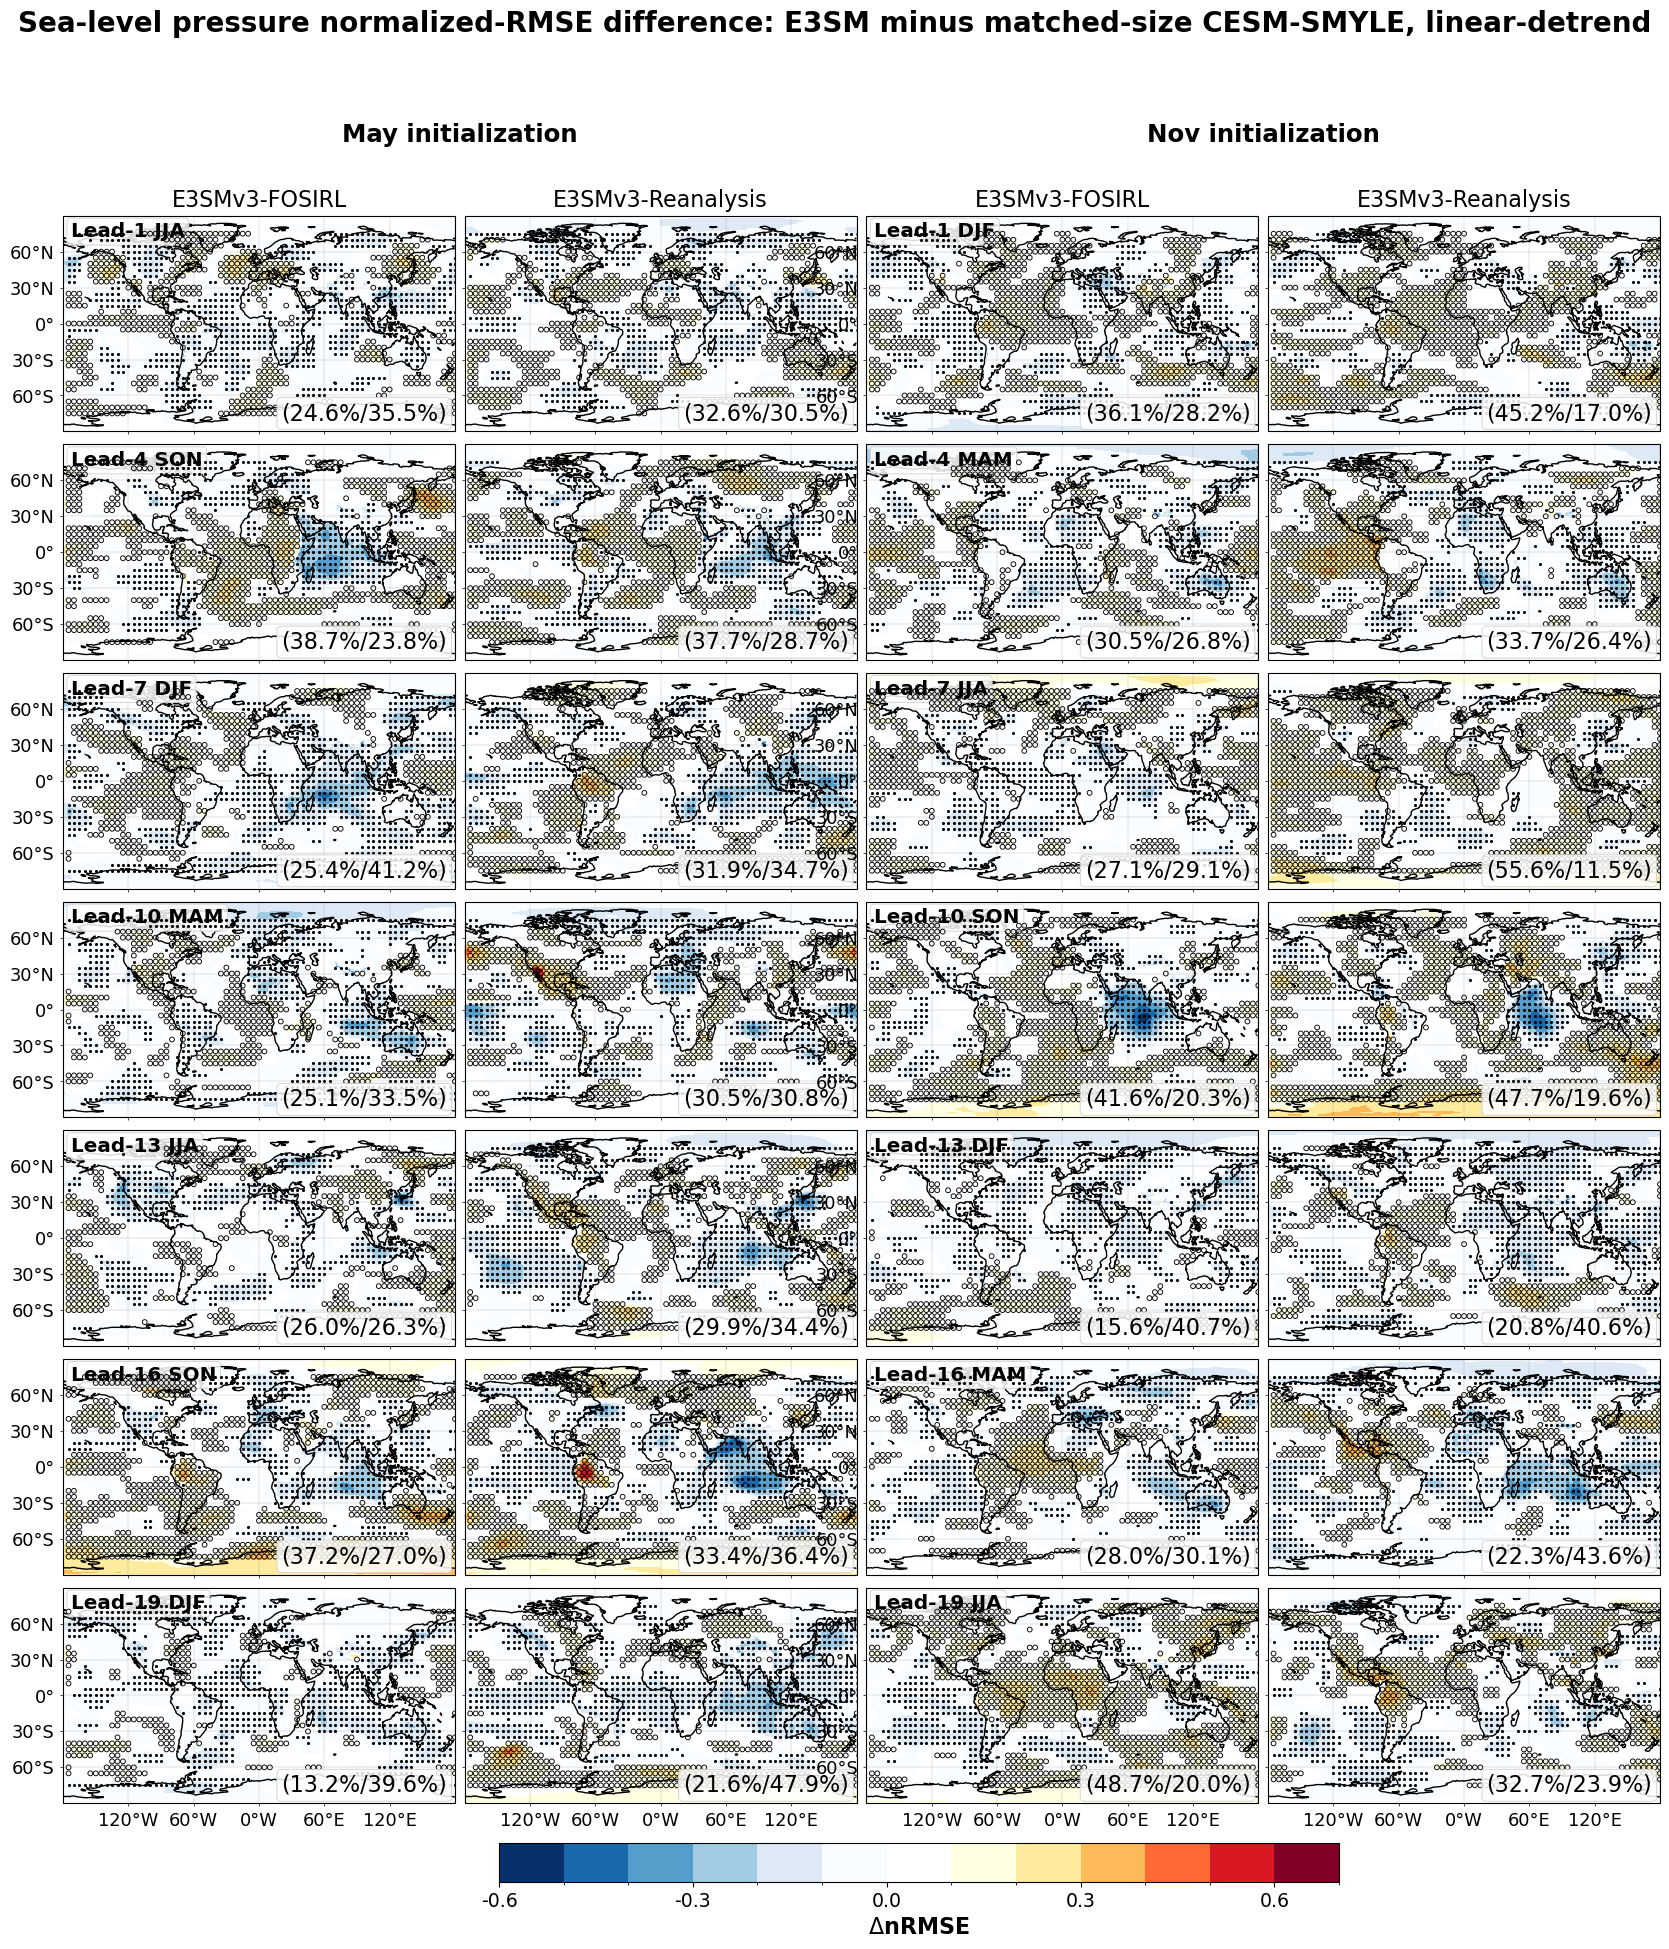

CPU times: user 20.7 s, sys: 1.62 s, total: 22.4 s
Wall time: 21.1 s


In [21]:
%%time
# Plot fixed E3SM nRMSE minus mean matched-size CESM-SMYLE nRMSE.
# All E3SM cases are shown in one figure, grouped by initialization month.
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.ticker as mticker

compare_init_months_plot = sorted(
    set(compare_init_months)
    & set(smyle_compare_skill_by_case_month[E3SM_REFERENCE_CASE])
)
if not compare_init_months_plot:
    raise RuntimeError(
        "No common initialization months are available. Run the preceding "
        "finite-ensemble comparison cell first."
    )
print("Plotting initialization months:", compare_init_months_plot)

# Use the normalized-RMSE-difference colorbar selected with `field` above.
diff_level_steps = np.diff(nrmse_diff_levels)
cmin = float(nrmse_diff_levels[0])
cmax = float(nrmse_diff_levels[-1])
ci = float(diff_level_steps[0])
latlim = 80
symclr = "black"
marker_stride = 5
open_marker_size = 12
filled_marker_size = 5
marker_linewidth = 0.65

compare_fontz = 16
compare_panel_title_size = compare_fontz
compare_lead_label_size = compare_fontz * 1.0
compare_lat_lon_label_size = compare_fontz * 0.8
compare_suptitle_size = compare_fontz * 1.25
compare_colorbar_label_size = compare_fontz
compare_colorbar_tick_size = compare_fontz * 0.85
compare_fweight = "bold"

area = destgrid.area
valid_area = xr.where(abs(destgrid.lat) < latlim, area, 0)
valid_area_sum = valid_area.sum()
lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)

# Retain only cases that can be compared in every requested initialization
# section. This keeps the May and November column groups symmetric.
available_compare_cases = []
for case_key in E3SM_COMPARE_CASES:
    has_all_months = all(
        m in smyle_compare_skill_by_case_month.get(case_key, {})
        and m in e3sm_compare_skill_by_case_month.get(case_key, {})
        and m in rmse_significance_by_case_month.get(case_key, {})
        for m in compare_init_months_plot
    )
    if has_all_months:
        available_compare_cases.append(case_key)
    else:
        print(f"Skipping {case_key}: incomplete initialization-month comparison data")

if not available_compare_cases:
    raise RuntimeError("No E3SM cases have complete data for the comparison figure.")

skilldiff_by_case_month = {
    case_key: {
        m: (
            e3sm_compare_skill_by_case_month[case_key][m]
            - smyle_compare_skill_by_case_month[case_key][m].mean("iteration")
        )
        for m in compare_init_months_plot
    }
    for case_key in available_compare_cases
}

first_case = available_compare_cases[0]
first_month = compare_init_months_plot[0]
candidate_leads = smyle_compare_skill_by_case_month[first_case][first_month].L.values
plot_leads = [
    int(lead) for lead in candidate_leads
    if all(
        bool(skilldiff_by_case_month[case_key][m].rmse.sel(L=lead).notnull().any())
        for m in compare_init_months_plot
        for case_key in available_compare_cases
    )
]
if not plot_leads:
    raise RuntimeError("No common finite seasonal RMSE leads are available.")

# Build all May model columns first and all November model columns second.
# Section headers below distinguish the two compact side-by-side groups.
column_specs = []
month_column_indices = {}
for compare_init_month in compare_init_months_plot:
    month_column_indices[compare_init_month] = []
    for case_key in available_compare_cases:
        month_column_indices[compare_init_month].append(len(column_specs))
        column_specs.append((compare_init_month, case_key))

nrows = len(plot_leads)
ncols = len(column_specs)
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(4.2 * ncols, 2.8 * nrows))
cntr = None
top_row_axes = {}

for i, lead in enumerate(plot_leads):
    for j, column_spec in enumerate(column_specs):
        compare_init_month, case_key = column_spec
        case_label = E3SM_CASES[case_key].get("display_name", case_key)
        smyle_skill = smyle_compare_skill_by_case_month[case_key][compare_init_month]
        skilldiff = skilldiff_by_case_month[case_key][compare_init_month]
        significance = rmse_significance_by_case_month[case_key][compare_init_month]
        title = case_label if i == 0 else ""
        subplot = i * ncols + j + 1

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            skilldiff.rmse.sel(L=lead),
            smyle_skill.lon,
            smyle_skill.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap="blue2red", cutoff=0.5,
            fontsize=compare_panel_title_size,
        )
        if i == 0:
            top_row_axes[j] = ax

        ax.set_xticks([-120, -60, 0, 60, 120], crs=ccrs.PlateCarree())
        ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(
                labelsize=compare_lat_lon_label_size,
                length=2.5,
                width=0.5,
                top=False,
                right=False,
                labelbottom=(i == nrows - 1),
                labelleft=(j == month_column_indices[compare_init_month][0]),
            )
        ax.gridlines(
                crs=ccrs.PlateCarree(),
                linewidth=0.35,
                color="0.35",
                alpha=0.35,
                linestyle="-",
                draw_labels=False,
            )

        # The lead/season is shared by every model in this initialization
        # section, so label it once rather than repeating it in every panel.
        if j == month_column_indices[compare_init_month][0]:
            section_leadstr = f"Lead-{lead - 2} {seasonal_label(compare_init_month, lead)}"
            ax.text(
                0.02, 0.97, section_leadstr,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=compare_lead_label_size * 0.9,
                fontweight=compare_fweight,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
                zorder=10,
            )

        valid = skilldiff.rmse.sel(L=lead).notnull()

        # Open circles: CESM-SMYLE robustly has lower nRMSE.
        bsmyle_better = (significance["right_better"].sel(L=lead) == 1) & valid
        tmparea = xr.where(bsmyle_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nbetter = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(bsmyle_better)[::marker_stride, ::marker_stride]
        display_lon = lon2d[::marker_stride, ::marker_stride]
        display_lat = lat2d[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
                display_lon[display_mask], display_lat[display_mask],
                facecolor="none", edgecolor=symclr,
                s=open_marker_size, linewidth=marker_linewidth, zorder=10,
            )

        # Filled dots: E3SM robustly has lower nRMSE.
        e3sm_better = (significance["left_better"].sel(L=lead) == 1) & valid
        tmparea = xr.where(e3sm_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nworse = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(e3sm_better)[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
                display_lon[display_mask], display_lat[display_mask],
                facecolor=symclr, edgecolor=symclr,
                s=filled_marker_size, linewidth=0, zorder=10,
            )

        ax.text(
                0.98, 0.03,
                f"({nbetter * 100:3.1f}%/{nworse * 100:3.1f}%)",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=compare_lead_label_size,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
                zorder=10,
            )

fig.suptitle(
    f"{cfg['plot_name']} normalized-RMSE difference: "
    "E3SM minus matched-size CESM-SMYLE, linear-detrend",
    fontsize=compare_suptitle_size,
    fontweight=compare_fweight,
    y=0.995,
)
fig.tight_layout(rect=[0.0, 0.08, 1.0, 0.89])
fig.subplots_adjust(top=0.89, bottom=0.08, hspace=0.06, wspace=0.025)

# Add a modest gap only between initialization sections. This keeps the
# models within each section close while preventing latitude-label overlap.
if len(compare_init_months_plot) > 1:
    section_step = 0.014
    section_center = 0.5 * (len(compare_init_months_plot) - 1)
    for section_index, compare_init_month in enumerate(compare_init_months_plot):
        x_shift = (section_index - section_center) * section_step
        for j in month_column_indices[compare_init_month]:
            for ax in axes_by_column[j]:
                position = ax.get_position()
                ax.set_position([
                    position.x0 + x_shift, position.y0,
                    position.width, position.height,
                ])

# Initialization headers span their model columns and make the left/right
# comparison structure explicit.
for compare_init_month, column_indices in month_column_indices.items():
    axes_for_month = [top_row_axes[j] for j in column_indices]
    left = min(ax.get_position().x0 for ax in axes_for_month)
    right = max(ax.get_position().x1 for ax in axes_for_month)
    init_label = init_month_names.get(compare_init_month, f"{compare_init_month:02d}").title()
    fig.text(
        0.5 * (left + right), 0.925, f"{init_label} initialization",
        ha="center", va="bottom",
        fontsize=compare_panel_title_size * 1.1,
        fontweight=compare_fweight,
    )

cbar_ax = fig.add_axes([0.3, 0.04, 0.5, 0.02])
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_ticks(nrmse_diff_ticks)
cbar.ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter(f"%.{nrmse_diff_decimals}f")
)
cbar.set_label(r"${\Delta}$nRMSE", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

skilldiff_figname = figure_filename(field, "multi_e3sm", "rmse_skill_diff")
skilldiff_figpath = FIGURE_OUTDIR / skilldiff_figname
mov.save_figure(
    fig, skilldiff_figpath,
    mode="",
    metric="leadtime_rmse_diff",
    title=f"Leadtime RMSE Difference: {field}, multi-E3SM comparison",
    caption=(
        "Normalized-RMSE differences between E3SM hindcasts and matched-size "
        "CESM-SMYLE ensembles, grouped by May and November initialization"
    ),
    dpi=300,
)
print("Saved figure:", skilldiff_figpath)
plt.show()

# Backward-compatible reference-case difference dictionary.
e3sm_compare_skilldiff_by_month = {
    m: e3sm_compare_skill_by_case_month[E3SM_REFERENCE_CASE][m] - smyle_compare_skill_by_case_month[E3SM_REFERENCE_CASE][m].mean("iteration")
    for m in compare_init_months_plot
}

